In [1]:
# File to plot hencky strain and energy consumption over time.
# The file is dependent on custom-written python files named
# "Localized_Energy_Consumption_Functionalized" and 
# "Strain_Div_EnergyCons_Functionalized". Those files must be saved
# as a python file, not a .ipynb file. 

In [2]:
# Load directories
# os for handling working folder
import os as os

# From Strain rate code
# To handle images, we have PIL - Image

from PIL import Image # PIL might be defunct 
import numpy as np  # Essential functions
import pandas as pd # Essential for dataframe and excel manipulation
import matplotlib.pyplot as plt # Essential data visualization
import matplotlib.style
import matplotlib as mpl

# Collection of image processing directories.
from skimage.filters import threshold_otsu #The binarization algorithm
from skimage.io import imread, imsave #Image processing
from skimage.morphology import reconstruction # For floodfill algorithm
%matplotlib inline

from sklearn.linear_model import LinearRegression # function that generates a linear fit. Might be defunct
from mpl_toolkits.axes_grid1 import make_axes_locatable # might be defunct.
from scipy.optimize import curve_fit # function that generates a linear fit. Might be defunct

#os.chdir('C://Users//franc//Box//ALAB Data Francis Cavanna//2021 Actomyosin Control//ProcessingStrainRate_Files')
import Localized_Energy_Consumption_Functionalized # custom program for dealing with energy consumption in .tif files.
import Strain_Div_EnergyCons_Functionalized # custom program for dealing with strain production in .tif files.

#Seaborn for making boxplots
import seaborn as sns # boxplots for fig 1e-f
import statannotations as sann # boxplots for fig 1e-f (might be defunct)
from statannotations.Annotator import Annotator # Automatic program for recognizing statistical significance.
import os.path as ospath # os.path used to check if the csv exists. Remove for first coding run.
from scipy.signal import savgol_filter # For smoothing energy measurement to get energy consumption rate measurements

import math as mt # For the floor function

In [3]:
# Change directory to master directory to make ease of use possible. (might be defunct)
os.chdir('C://Users//franc//Box//ALAB Data Francis Cavanna//2021 Actomyosin Control//')

In [4]:
# Create list of folders I want to process
base = "C://Users//franc//Box//ALAB Data Francis Cavanna//2021 Actomyosin Control" # Base file location
# '2022_1_28', '2022_1_31', '2022_2_25','2022_3_13_Anthony//3-13-2022//0,6_F-0,12_M-1', 
               #'2022_3_13_Anthony//3-13-2022//0,6_F-0,12_M-2', 
List_folder = ['2022_1_28', '2022_1_31', '2022_2_25','2022_3_13_Anthony//3-13-2022//0,6_F-0,12_M-1', 
               '2022_3_13_Anthony//3-13-2022//0,6_F-0,12_M-2','2022_3_13_Anthony//3-13-2022//0,6_F-0,12_M-3',
              '2022_3_13_Anthony//3-13-2022//1,2 F-0,06 M-1', '2022_3_13_Anthony//3-13-2022//1,2 F-0,12 M-1',
               '2022_3_15_Anthony//1,2 F-0,24 M-1','2022_3_15_Anthony//1,2 F-0,24 M-2','2022_4_16','2023_2_03//fascin']
                # List of folders containing data you would want to process

DAPI_folder = '\StrainRateFiles\DAPI\\' # Select relevant PLUM folders

PLUM_folder = '\StrainRateFiles\PLUM\\' # Select relevant DAPI folders

List_folder_Reduced = ['2022_1_28', '2022_1_31', '2022_2_25',
              '2022_3_13_Anthony//3-13-2022//1,2 F-0,06 M-1', '2022_3_13_Anthony//3-13-2022//1,2 F-0,12 M-1',
               '2022_3_15_Anthony//1,2 F-0,24 M-1','2022_3_15_Anthony//1,2 F-0,24 M-2','2022_4_16']
                # List of folders containing data you would want to process, without the extra fascin
List_folder_TTest = ['2022_1_28','2022_3_15_Anthony//1,2 F-0,24 M-1','2022_3_15_Anthony//1,2 F-0,24 M-2',
                    "2022_10_20//Actin_12uM_Fascin_10_Myosin_50_1","2022_10_20//Actin_12uM_Fascin_10_Myosin_50_2",
              "2022_10_22"]


In [5]:
List_folder_fascin_alpha = ['2022_3_13_Anthony//3-13-2022//0,6_F-0,12_M-3','2022_3_13_Anthony//3-13-2022//1,2 F-0,06 M-1', 
                '2022_3_13_Anthony//3-13-2022//1,2 F-0,12 M-1','2023_1_31','2023_2_03//fascin','2023_2_03//alpha']

In [6]:
# Define necessary filenames

# This block assigns the directory we work in, and the filenames we generate and use.

# Specify the overarching path for our filenames.
path = "C:\\Users\\franc\\Box\\ALAB Data Francis Cavanna\\2021 Actomyosin Control\\"

# Specify originator Excel Document from MolarConcentration.nb program:
MCfilename = "MathematicaDF.csv"

suffix = '.tif'

ECfolder = 'StrainRateFiles\\EnergyConsumpVideos\\'

ED_folder = 'StrainRateFiles\\Energy_Difference\\'



In [7]:
# truncate = 0

# #Start function for calculating strain here:
# def Calc_StrainRates(images,filenames,folder):

#     #Create list to hold pixel areas.
#     areas = []

#     #Create list of filenames so we can pull out the images and process them.
#     for i in range(0,len(images)):
#         fill = images[i]
#         fn = filenames[i]

#         imsave(fn + ".jpeg",fill)   # This causes the "Lossy conversion error". To fix, it's possible to convert the float64
#         # numerical type to a uint8 number type. I'm not going to do this right now.

#         # Sum the number of pixels in the image to get an area. This will be used to calculate Hencky Strain.
#         area = sum(sum(fill))
#         areas.append(area)

#     # Square the total area covered by pixels to get a length measurement. This is used to calculate Hencky Strain.
#     lengths = np.asarray(areas)**(1/2)
#     #print(areas[15])
#     #Once we process these iamges, we need to get a timescale. 
    
#     #The number of frames of data is 91. The number of measurements of Hencky Strain we get is 89. 
#     # Hencky Strain is calculated by a difference of length scales; the maximum we can get in infitesimal steps is 90.
#     # To get time derivative in hencky strain we must take Euler's approximation for the derivative. So that's 89 measurements.
#     # Time derivative in Hencky strain is also centered on 20s to 1780s datapoints.
#     frames = np.arange(0,N_slices-2)
#     times = frames * 20

#     henckyStrainDerivative = []
#     sum_strain = []
#     sum_strain_value = 0.0
#     times = []

#     # We now calculate the hencky strain using Euler's algorithm. 
#     for i in range(0, len(lengths)-1):
#         # Pull difference in lengths to get incremental change in strain.
#         dl = lengths[i+1] - lengths[i]
#         # Calculate square root difference in areas over a timestep for incremental change in area squared.
#         Diff = -np.sqrt(np.absolute(areas[i] - areas[i+1]))

#         # Calculate time derivative of hencky Strain
#         henckyStrainDerivative.append(dl/lengths[i]/20.0)

#         #Calculate Hencky Strain at each point in time.
#         if i >= truncate:
#             sum_strain_value = sum_strain_value + dl/lengths[i]
#             sum_strain.append(sum_strain_value)

#         times.append((i+1)*20.0)

#     # Pull out the highest strain and rescale the strain so it plots nicely
#     a = np.amax(sum_strain)

#     for i in range(0,len(sum_strain)):
#         sum_strain[i] = sum_strain[i] - a

#     # We now save the data in the format "Total Strain" (unitless), "infinitesimal Strain/time" (s^-1), "time" (s)
#     Data = [sum_strain,henckyStrainDerivative,times]
    
#     # Take care of previous strains.csv file which may or may not exist.
#     if ospath.exists(path + folder + '\Results//Strains.csv') is True:
#         # Delete the previous Strains.csv
#         os.remove(path + folder + '\Results//Strains.csv')
#     else:
#         pass
#     # Turn into a dataframe to save the file.
#     df = pd.DataFrame(Data)
#     # save to collect strain rates from the csv.
#     df.to_csv(path + folder + '\Results//Strains.csv', index=False, mode='a',header=False)
    
#     pixel_length = 0.7692 #microns per pixel
#     height = 152.9 #microns
#     Length_Data = [lengths, pixel_length*lengths,(pixel_length*lengths/4+height*pixel_length*lengths/np.sqrt(areas[0])/pixel_length),times]
#     Length_dict = ['pixels','length (um)','Volume/SurfaceAr','Time (s)']
    
#     df2 = pd.DataFrame(Length_Data,Length_dict)
#     if ospath.exists(path + folder + '\Results//MattiaRep.csv') is True:
#         # Delete the previous Strains.csv
#         os.remove(path + folder + '\Results//MattiaRep.csv')
#     else:
#         pass
#     # Turn into a dataframe to save the file.
#     df2.to_csv(path + folder + '\Results//MattiaRep.csv', index=True, mode='a',header=False)

In [44]:
# Call functions that generate csvs with Energy and Strain measurements.

# This block of code seems to generate some sort of error that disappears after being run 12 times.
# I don't know what it is, couldn't replicate it. I couldn't resolve it either. 

# Furthermore, this block takes a long time to run. If you are happy with the csvs that we already have,
# This code can be commented out.


#for i in range(0,12):
for i in [7]:
    print(List_folder[i])
    # Pull individual PLUM tif filenames out for processing

    # Check folder containing PLUM files for filenames and import them.
    PLUM_Search_folder = path + List_folder[i] + PLUM_folder
        #Collect individual names in folder
    Pnames = os.listdir(PLUM_Search_folder)
    

    # Collect names of PLUM files and find the .tif files. Some of these folders contain .jpgs for
    # manual review.
    Ptif_names = []
    for x in range(len(Pnames)):
        string = Pnames[x]
        if string.endswith('.tif'):
            Ptif_names.append(string[0:-8])

    # Get a base filename for our PLUM files
    PLUM_base = Ptif_names[i]


    ##### Do the same for DAPI tif filenames

    # Check folder containing DAPI files for filenames and import them.
    DAPI_Search_folder = path + List_folder[i] + DAPI_folder
    Dnames = os.listdir(DAPI_Search_folder)
    
    # Collect names of DAPI files and find the .tif files. Some of these folders contain .jpgs for
    # manual review.
    Dtif_names = []
    for x in range(len(Dnames)):
        string = Dnames[x]
        if string.endswith('.tif'):
            Dtif_names.append(string[0:-8])
    
    # Get a base filename for our DAPI files
    DAPI_base = Dtif_names[i]
    
    # Specify number of slices
    N_slices = 91

    # Collect an array of filenames to load images
    filenames_PLUM = []
    filenames_DAPI = []
    PLUM_savenames = []
    DAPI_savenames = []
    for n in np.arange(1,N_slices):

        # Convert integer to 0001 format. These are the filenames that actually pull our .tif files.
        number04d = format("%04d"% (n))

        # Connect base, format, and suffix to make a filename
        #filename = base + suffix
        filename_PLUM = List_folder[i] + PLUM_folder + PLUM_base + number04d + suffix
        filename_DAPI = List_folder[i] + DAPI_folder + DAPI_base + number04d + suffix
        PLUM_savename = ECfolder + PLUM_base + number04d
        DAPI_savename = ED_folder + DAPI_base + number04d

        # Append to filenames
        filenames_PLUM.append(filename_PLUM)
        filenames_DAPI.append(filename_DAPI)
        PLUM_savenames.append(PLUM_savename)
        DAPI_savenames.append(DAPI_savename)

    # Threshold PLUM images
    C1images = []
    for fn in filenames_PLUM:
        C1images.append(Localized_Energy_Consumption_Functionalized.Thresholding(fn))
        
    ########## CURRENTLY THIS CALCULATES FREE ENERGY PER LITER.
    Strain_Div_EnergyCons_Functionalized.Calc_StrainRates(C1images,filenames_PLUM,List_folder[i])
    #Calc_StrainRates(C1images,filenames_PLUM,List_folder[i])
    Localized_Energy_Consumption_Functionalized.Find_Energy(List_folder[i], filenames_DAPI, C1images)

2022_3_13_Anthony//3-13-2022//1,2 F-0,12 M-1


C:\Users\franc\Box\ALAB Data Francis Cavanna\2021 Actomyosin Control\ProcessingStrainRate_Files\Strain_Div_EnergyCons_Functionalized.py:77: UserWarning: 2022_3_13_Anthony//3-13-2022//1,2 F-0,12 M-1\StrainRateFiles\PLUM\1,2 F-0,12 M-Red-10001.tif.jpeg is a low contrast image
  imsave(fn + ".jpeg",fill)   # This causes the "Lossy conversion error". To fix, it's possible to convert the float64
Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
C:\Users\franc\Box\ALAB Data Francis Cavanna\2021 Actomyosin Control\ProcessingStrainRate_Files\Strain_Div_EnergyCons_Functionalized.py:77: UserWarning: 2022_3_13_Anthony//3-13-2022//1,2 F-0,12 M-1\StrainRateFiles\PLUM\1,2 F-0,12 M-Red-10002.tif.jpeg is a low contrast image
  imsave(fn + ".jpeg",fill)   # This causes the "Lossy conversion error". To fix, it's possible to convert the float64
Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving 

Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float64 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float64 to uint8. Range [0

<Figure size 432x288 with 0 Axes>

In [9]:
# #Code for pure testing Find_Energy
# # Specify number of slices
# # Pull individual PLUM tif filenames out for processing

# PLUM_Search_folder = path + List_folder[0] + PLUM_folder
# print(PLUM_Search_folder)
#     #Collect individual names in folder
# Pnames = os.listdir(PLUM_Search_folder)
# Ptif_names = []

# for x in range(len(Pnames)):
#     string = Pnames[x]
#     if string.endswith('.tif'):
#         Ptif_names.append(string[0:-8])

# PLUM_base = Ptif_names[0]
# #print(Ptif_names)


# ##### Do the same for DAPI tif filenames

# DAPI_Search_folder = path + List_folder[0] + DAPI_folder
# Dnames = os.listdir(DAPI_Search_folder)
# Dtif_names = []

# for x in range(len(Dnames)):
#     string = Dnames[x]
#     if string.endswith('.tif'):
#         Dtif_names.append(string[0:-8])
# #print(DAPI_Search_folder)
# DAPI_base = Dtif_names[0]
# #print(Dtif_names)

# filenames_PLUM = []
# filenames_DAPI = []
# PLUM_savenames = []
# DAPI_savenames = []

# N_slices = 90

# for n in np.arange(0,N_slices):

#     # Convert integer to 0001 format
#     number04d = format("%04d"% (n))

#     # Connect base, format, and suffix to make a filename
#     filename = base + suffix
#     filename_PLUM = List_folder[0] + PLUM_folder + PLUM_base + number04d + suffix
#     filename_DAPI = List_folder[0] + DAPI_folder + DAPI_base + number04d + suffix
#     PLUM_savename = ECfolder + PLUM_base + number04d
#     DAPI_savename = ED_folder + DAPI_base + number04d

#     # Append to filenames
#     filenames_PLUM.append(filename_PLUM)
#     filenames_DAPI.append(filename_DAPI)
#     PLUM_savenames.append(PLUM_savename)
#     DAPI_savenames.append(DAPI_savename)

# C1images = []
# for fn in filenames_PLUM:
#     C1images.append(Localized_Energy_Consumption_Functionalized.Thresholding(fn))
    
# Localized_Energy_Consumption_Functionalized.Find_Energy(List_folder[0], filenames_DAPI, C1images)

In [54]:
# This block of code seems to generate some sort of error that disappears after being run 12 times.
# I don't know what it is, couldn't replicate it. I couldn't resolve it either. 

# Plot your hard work. This is the plots section

Cutoff = [7,4,9,16,12,8,3,11,11,9,8] # Custom based cutoff for splitting fitted log-log plots

Myosin_Conditions = [0.24,0.06,0.12,0.12,0.12,0.12,0.06,0.12,0.24,0.24,0.12,0.06]
#Numerical representation of myosin conditions

Fascin_Conditions = ['1.2', '1.2', '1.2', '2.4', '2.4','2.4','1.2','1.2','1.2','1.2','1.2','1.2'] 
# String representation of fascin conditions

Actin_Conditions = ['12','12','12','12','12','12','12','12','12','12','12','12']
# String representation of actin conditions

#List_Colors = ['r-','g--','b-.','m:','m:','m:','g--','b-.','r-','r-','b-.','g--'] 
# List of colors to use in plots across multiple conditions

List_Colors = ['r:','tab:orange','g-.','b-.','b-.','b-.','tab:orange','g-.','r:','r:','g-.','tab:orange'] 
# List of colors to use in plots across multiple conditions

Ordered_Folders = [5,1,2,0,3,4,6,7,8,9,10,11]
# Collection of folders that plot conditions to correspond to certain colors.

Ordered_Legend = []
# List for a legend with fixed number of colors.

List_Legend = [r'$R_F = \frac{1}{10} \; \; R_M = \frac{1}{50}$',r'$R_F = \frac{1}{10} \; \; R_M = \frac{1}{200}$',
                r'$R_F = \frac{1}{10} \; \; R_M = \frac{1}{100}$',r'$R_F = \frac{1}{20} \; \; R_M = \frac{1}{100}$',
                r'$R_F = \frac{1}{20} \; \; R_M = \frac{1}{100}$',r'$R_F = \frac{1}{20} \; \; R_M = \frac{1}{100}$',
                r'$R_F = \frac{1}{10} \; \; R_M = \frac{1}{200}$',r'$R_F = \frac{1}{10} \; \; R_M = \frac{1}{100}$',
                r'$R_F = \frac{1}{10} \; \; R_M = \frac{1}{50}$' ,r'$R_F = \frac{1}{10} \; \; R_M = \frac{1}{50}$',
               r'$R_F = \frac{1}{10} \; \; R_M = \frac{1}{100}$',r'$R_F = \frac{1}{10} \; \; R_M = \frac{1}{200}$'] 
# Legend representation for different conditions

File_Legend = ['RF=1l10 RM=1l50_1','RF=1l10 RM=1l200_1',
                'RF=1l10 RM=1l100_1','RF=1l20 RM=1l100_1',
                'RF=1l20 RM=1l100_2','RF=1l20 RM=1l100_3',
                'RF=1l10 RM=1l200_2','RF=1l10 RM=1l100_2',
                'RF=1l10 RM=1l50_2' ,'RF=1l10 RM=1l50_3',
               'RF=1l10 RM=1l100_3','RF=1l10 RM=1l200_3'] 



#Move to log-log plots
#def exponential(x,a,b,c,d):
#    return a*np.exp(b*x+c)+d


# Set fontsize --- move to log-log plots
ftsz = 20
tcksz = 14

# Collect individual datasets from folder. The programs that generate these csv's is in Localized_Energy_Consumption
# and Strain_Div_EnergyCons_Functionalized files. You have to export the ipynb files as py files and then store them
# in the same folder as this file here.

# DF_Strain_List and DF_Energy_List become arrays of arrays. We pull out material from these individually later.
DF_Strain_List = []
DF_Energy_List = []
for i in range(len(List_folder)):
    
    # Pull individual datasets out for processing

    DataStrain_Search_folder = path + List_folder[i] + '\Results\Strains.csv'
    DataEnergy_Search_folder = path + List_folder[i] + '\Results\Energies.csv'
    print(DataStrain_Search_folder)
    Strains = pd.read_csv(DataStrain_Search_folder,header=None)
    Energies = pd.read_csv(DataEnergy_Search_folder,header=None)
    #print(Energies.iloc[:,1:])
    #print(Strains)
    DF_Strain_List.append(Strains)
    DF_Energy_List.append(Energies.iloc[:,1:])

C:\Users\franc\Box\ALAB Data Francis Cavanna\2021 Actomyosin Control\2022_1_28\Results\Strains.csv
C:\Users\franc\Box\ALAB Data Francis Cavanna\2021 Actomyosin Control\2022_1_31\Results\Strains.csv
C:\Users\franc\Box\ALAB Data Francis Cavanna\2021 Actomyosin Control\2022_2_25\Results\Strains.csv
C:\Users\franc\Box\ALAB Data Francis Cavanna\2021 Actomyosin Control\2022_3_13_Anthony//3-13-2022//0,6_F-0,12_M-1\Results\Strains.csv
C:\Users\franc\Box\ALAB Data Francis Cavanna\2021 Actomyosin Control\2022_3_13_Anthony//3-13-2022//0,6_F-0,12_M-2\Results\Strains.csv
C:\Users\franc\Box\ALAB Data Francis Cavanna\2021 Actomyosin Control\2022_3_13_Anthony//3-13-2022//0,6_F-0,12_M-3\Results\Strains.csv
C:\Users\franc\Box\ALAB Data Francis Cavanna\2021 Actomyosin Control\2022_3_13_Anthony//3-13-2022//1,2 F-0,06 M-1\Results\Strains.csv
C:\Users\franc\Box\ALAB Data Francis Cavanna\2021 Actomyosin Control\2022_3_13_Anthony//3-13-2022//1,2 F-0,12 M-1\Results\Strains.csv
C:\Users\franc\Box\ALAB Data Fran

In [55]:
# Here we pull out strains and energy values from my lists individually.



Strain_List = [] # Strain
Strain_Abs = [] # Absolute value of strain
Strain_ListN = [] # Normalized strain
StrainRate_List = [] # Euler approximation for strain derivative, normalized by its smallest value
Energy_List = [] # Energy
Energy_ListN = [] # Normalized Energy
Energy_Max = [] # List for maximum values of energy consumption across multiple experimental conditions
EnergyRate_List = [] # Euler approximation for energy 
Smooth1_EnergyRate_List = [] # First method for calculating smoothed energy.
Smooth2_EnergyRate_List = [] # The Savitzky-Golay smoothing algorithm for smoothed energy.
Times_List = [] # List of times used. Must be caerful to pair strain, energy, and times appropriately.
SmallTimes_List = [] # List of ficticious times used to make curve fitting functions in python work properly
Response_Func = [] # The strain divided by the energy
Response_Func_Mstr = [] # The strain divided by the energy, normalized by each other.

FitExponent_List = []

for i in range(len(List_folder)):
    # Append strains to each list
    Strains = list(DF_Strain_List[i].iloc[0])
    #print(Strains)
    Strain_Abs.append(np.abs(Strains))
    StrainsN = [x/np.min(Strains) for x in Strains]
    Strain_ListN.append(StrainsN)
    Strains = Strains/np.min(Strains)
    Strain_List.append(Strains)
    
    #Append strain rates to each list
    Strain_Rates = list(DF_Strain_List[i].iloc[1])
    #Strain_Rates = [np.abs(x/np.min(Strain_Rates)) for x in Strain_Rates] # We normalize strain rates
    StrainRate_List.append(Strain_Rates)
    
    #Append energy to each list
    Energies = list(DF_Energy_List[i].iloc[0])
    Energy_List.append(Energies)
    EnergiesN = [x/np.max(Energies) for x in Energies]
    Energy_ListN.append(EnergiesN)
    Energy_Max.append(np.max(Energies))
    
    #Process Energy Rate
    Energy_Rates = list(DF_Energy_List[i].iloc[1])
    EnergyRate_List.append(list(Energy_Rates))
    
    #Get simple moving averages of Energy to calculate Finite Difference Energy Rate
    window_size = 5
    j = 0
    # Initialize an empty list to store moving averages
    Energy_moving_averages = []
    # Loop through the array to consider every window of size 5
    while j < len(Energy_List[i]) - window_size + 1:
        # Calculate the average of current window
        window_average = round(np.sum(Energy_List[i][j:j+window_size])/window_size, 2)
        # Store the average of current window in moving average list
        Energy_moving_averages.append(window_average)
        # Shift window to right by one position
        j += 1

    # Recompute energy consumption rates for data
    HolderER = []
    for k in range(0,len(Energy_moving_averages)-1):
        diff1 = (Energy_moving_averages[k+1]-Energy_moving_averages[k])/20
        HolderER.append(diff1)
        #This list is truncted on both sides by 3 indices. Our proper time indice
        # is now time[3:86]
    #print(HolderER)
    Smooth1_EnergyRate_List.append(HolderER)  
    
    # Now calculate smoothed energy rates with Savitzky-Golvay algorithm
    Energy_Savgol = savgol_filter(Energy_List[i], 11, 3)
    HolderER = []
    for k in range(0,len(Energy_Savgol)-1):
        diff1 = (Energy_Savgol[k+1]-Energy_Savgol[k])/20
        HolderER.append(diff1)
    Smooth2_EnergyRate_List.append(HolderER)
    
    #Process Time
    Times = list(DF_Strain_List[i].iloc[2])
    #print(Times)
    SmallTimes = [x/1000.0 for x in Times]
    Times_List.append(Times)
    SmallTimes_List.append(SmallTimes)
    
    Strain_dV_G = np.min(list(DF_Strain_List[i].iloc[0]))/np.max(list(DF_Energy_List[i].iloc[0]))
    Response_Func.append(Strain_dV_G)
    Response_Func_Indv = []
    

#     for j in range(1,len(list(DF_Energy_List[i].iloc[0]))):
#         if (i == 9):
#             x = list(DF_Strain_List[i].iloc[0,0:59])
#             jep = list(DF_Energy_List[i].iloc[0,0:59])
#             if (j <=58):
#                 Indv_Strain_dV_G = np.abs(x[j])/jep[j]*np.max(jep)/np.max(x)
#                 Response_Func_Indv.append(Indv_Strain_dV_G)
#             else:
#                 pass
#         else:
#             x = list(DF_Strain_List[i].iloc[0])
#             jep = list(DF_Energy_List[i].iloc[0])
#             Indv_Strain_dV_G = np.abs(x[j])/jep[j]*np.max(jep)/np.min(x)
#             Response_Func_Indv.append(Indv_Strain_dV_G)
#     Response_Func_Mstr.append(Response_Func_Indv)
    
    # Create strain and energy plots for individual experiments.
    #print(List_folder[i])
#     Strain_Div_EnergyCons_Functionalized.Create_Strain_Plot(path,List_folder[i])
#     Strain_Div_EnergyCons_Functionalized.Dervs(DF_Energy_List[i].iloc[1],DF_Strain_List[i].iloc[1],Times,path,List_folder[i])
    
#     # These are exceptions that allow me to fit exponential functions to datasets that would otherwise not be amenable to
#     # curve fitting. May not be valid anymore.
#     if (i == 8):
#         FitExponent_List.append(Strain_Div_EnergyCons_Functionalized.find_exponential(DF_Energy_List[i].iloc[0],DF_Strain_List[i].iloc[0,0:88],Times[0:88],path,List_folder[i]))
#         #FitExponent_List.append(Strain_Div_EnergyCons_Functionalized.find_exponential(DF_Energy_List[i].iloc[0,0:13],DF_Strain_List[i].iloc[0,0:13],Times[0:13],path,List_folder[i]))
#     elif (i == 9):
#         FitExponent_List.append(Strain_Div_EnergyCons_Functionalized.find_exponential(DF_Energy_List[i].iloc[0,0:59],DF_Strain_List[i].iloc[0,0:59],Times[0:59],path,List_folder[i]))
#         #FitExponent_List.append(Strain_Div_EnergyCons_Functionalized.find_exponential(DF_Energy_List[i].iloc[0,0:10],DF_Strain_List[i].iloc[0,0:10],Times[0:13],path,List_folder[i]))
#     else: 
#         FitExponent_List.append(Strain_Div_EnergyCons_Functionalized.find_exponential(DF_Energy_List[i].iloc[0,0:88],DF_Strain_List[i].iloc[0,0:88],Times,path,List_folder[i]))

# print(FitExponent_List)

In [46]:
print(len(Energy_Savgol))

88


In [47]:
# This block of code generates an error. I'm not sure why, I don't know what it generates.

# # Fit the absolute strain to another exponent.
# #print(len(List_folder))
# FitExponent_Abs = []

# # The exceptions presented for absolute values are not needed any more. ???
# for i in range(len(List_folder)):
#     print(i)
#     if (i == 8):
#         FitExponent_Abs.append(Strain_Div_EnergyCons_Functionalized.abs_exponential(SmallTimes_List[i],Strain_Abs[i],Times,path,List_folder[i]))
#     elif (i == 9):
#         FitExponent_Abs.append(Strain_Div_EnergyCons_Functionalized.abs_exponential(SmallTimes_List[i][0:59],Strain_Abs[i][0:59],Times[0:59],path,List_folder[i]))
#     else: 
#         FitExponent_Abs.append(Strain_Div_EnergyCons_Functionalized.abs_exponential(SmallTimes_List[i],Strain_Abs[i],Times,path,List_folder[i]))

# # print(FitExponent_Abs)

In [24]:
# Set fontsize --- move to log-log plots
ftsz = 25
tcksz = 21
#ftsz = 20
#tcksz = 14

In [25]:
# # Plot the Energy (J/L) vs Time, with ordered folders

# fig = plt.figure(figsize=(8,6))
# ax1 = fig.add_subplot(111)
# #temperature = times[0:len(Times_List)]

# Legend_Used = []

# #for i in [8,9,10,11]:
# for i in Ordered_Folders:#range(len(List_folder)):
#     #print(Energy_List[i])
#     if (i == 9):
#         ax1.plot(Times_List[i][0:len(Energy_List[i])], Energy_List[i], List_Colors[i])
#         #ax1.plot(Times_List[i][0:59], Energy_List[i][0:59], List_Colors[i])
#     elif List_Legend[i] in Legend_Used:
#         ax1.plot(Times_List[i][0:len(Energy_List[i])], Energy_List[i], List_Colors[i])
#     else:
#         ax1.plot(Times_List[i][0:len(Energy_List[i])], Energy_List[i], List_Colors[i], label=List_Legend[i])
#         Legend_Used.append(List_Legend[i])
# #plt.title('Normalized Energy vs Time (s)')
# plt.ylabel('$g$ (J/L)',fontsize=ftsz,rotation=0)
# plt.xlabel('$t \: (\mathrm{s})$',fontsize=ftsz)
# plt.legend(loc="upper left",prop={'size': 15})
# plt.ylim(0.0,60)
# ax1.yaxis.set_label_coords(-0.2,0.5)
# plt.tick_params(axis='both', which='major', labelsize=tcksz)
# #plt.xlim(0,100)

# plt.savefig(base + '//ProcessingStrainRate_Files//Graphs//E_vs_t.png',dpi="figure",format="png",bbox_inches='tight')

# plt.show()

# # Questionable energy consumption plots in folders 8, 9, 10, 11

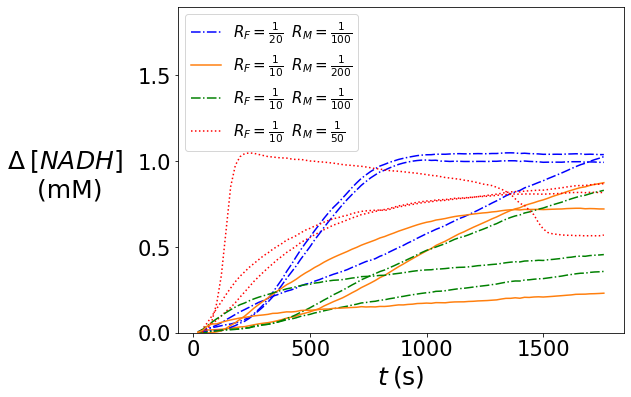

In [26]:
# Plot the ATP change in molarity vs Time, with ordered folders

fig = plt.figure(figsize=(8,6))
ax1 = fig.add_subplot(111)
#temperature = times[0:len(Times_List)]

Legend_Used = []



#for i in [8,9,10,11]:
for i in Ordered_Folders:#range(len(List_folder)):
    #print(Energy_List[i])
    if (i == 9):
        Molarity = [x/56.0 for x in Energy_List[i]]
        ax1.plot(Times_List[i][0:len(Energy_List[i])], Molarity, List_Colors[i])
        #ax1.plot(Times_List[i][0:59], Energy_List[i][0:59], List_Colors[i])
    elif List_Legend[i] in Legend_Used:
        Molarity = [x/56.0 for x in Energy_List[i]]
        ax1.plot(Times_List[i][0:len(Energy_List[i])], Molarity, List_Colors[i])
    else:
        Molarity = [x/56.0 for x in Energy_List[i]]
        ax1.plot(Times_List[i][0:len(Energy_List[i])], Molarity, List_Colors[i], label=List_Legend[i])
        Legend_Used.append(List_Legend[i])
#plt.title('Normalized Energy vs Time (s)')
plt.ylabel('$\Delta \: [NADH]$ \n (mM)',fontsize=ftsz,rotation=0)
plt.xlabel('$t \: (\mathrm{s})$',fontsize=ftsz)
plt.legend(loc="upper left",prop={'size': 15})
plt.ylim(0.0,1.9)
ax1.yaxis.set_label_coords(-0.25,0.4)
plt.tick_params(axis='both', which='major', labelsize=tcksz)
#plt.xlim(0,100)

plt.savefig(base + '//ProcessingStrainRate_Files//Graphs//Molarity_vs_t.png',dpi="figure",format="png",bbox_inches='tight')

plt.show()

# Questionable energy consumption plots in folders 8, 9, 10, 11

In [27]:
# # Plot the Energy (J/L) vs Time, with an ordered list, and truncated datasets

# fig = plt.figure(figsize=(8,6))
# ax1 = fig.add_subplot(111)
# #temperature = times[0:len(Times_List)]

# Legend_Used = []

# #for i in [1,2,3]:
# for i in Ordered_Folders:#[9,3,4]:
#     if (i == 9):
#         ax1.plot(Times_List[i][0:8], Energy_List[i][0:8], List_Colors[i])
#     elif (i == 3):
#         ax1.plot(Times_List[i][0:34], Energy_List[i][0:34], List_Colors[i])
#     elif (i == 4):
#         ax1.plot(Times_List[i][0:35], Energy_List[i][0:35], List_Colors[i])
#     elif List_Legend[i] in Legend_Used:
#         ax1.plot(Times_List[i][0:len(Energy_List[i])], Energy_List[i], List_Colors[i])
#     else:
#         ax1.plot(Times_List[i][0:len(Energy_List[i])], Energy_List[i], List_Colors[i], label=List_Legend[i])
#         Legend_Used.append(List_Legend[i])
# #plt.title('Normalized Energy vs Time (s)')
# plt.ylabel('$g$ (J/L)',fontsize=ftsz,rotation=0)
# plt.xlabel('$t \: (\mathrm{s})$',fontsize=ftsz)
# plt.legend(loc="upper left",prop={'size': 15})
# plt.ylim(0.0,55)
# ax1.yaxis.set_label_coords(-0.2,0.5)
# plt.tick_params(axis='both', which='major', labelsize=tcksz)
# #plt.xlim(0,100)

# plt.savefig(base + '//ProcessingStrainRate_Files//Graphs//E_vs_t_ALT2.png',dpi="figure",format="png",bbox_inches='tight')

# plt.show()

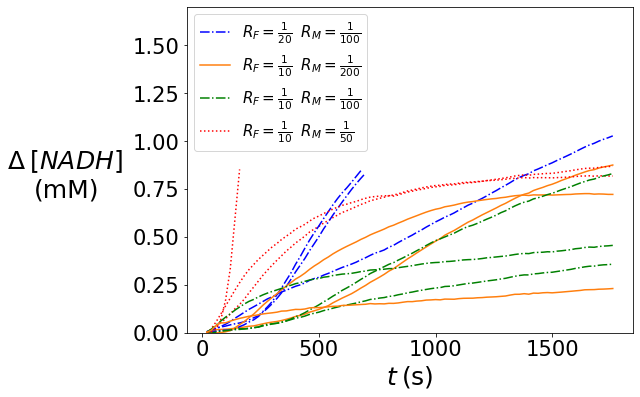

In [28]:
# Plot the Energy (J/L) vs Time, with an ordered list, and truncated datasets

fig = plt.figure(figsize=(8,6))
ax1 = fig.add_subplot(111)
#temperature = times[0:len(Times_List)]

Legend_Used = []

#for i in [1,2,3]:
for i in Ordered_Folders:#[9,3,4]:
    if (i == 9):
        Molarity = [x/56.0 for x in Energy_List[i]]
        ax1.plot(Times_List[i][0:8], Molarity[0:8], List_Colors[i])
    elif (i == 3):
        Molarity = [x/56.0 for x in Energy_List[i]]
        ax1.plot(Times_List[i][0:34], Molarity[0:34], List_Colors[i])
    elif (i == 4):
        Molarity = [x/56.0 for x in Energy_List[i]]
        ax1.plot(Times_List[i][0:35], Molarity[0:35], List_Colors[i])
    elif List_Legend[i] in Legend_Used:
        Molarity = [x/56.0 for x in Energy_List[i]]
        ax1.plot(Times_List[i][0:len(Energy_List[i])], Molarity, List_Colors[i])
    else:
        Molarity = [x/56.0 for x in Energy_List[i]]
        ax1.plot(Times_List[i][0:len(Energy_List[i])], Molarity, List_Colors[i], label=List_Legend[i])
        Legend_Used.append(List_Legend[i])
#plt.title('Normalized Energy vs Time (s)')
plt.ylabel('$\Delta \: [NADH]$ \n(mM)',fontsize=ftsz,rotation=0)
plt.xlabel('$t \: (\mathrm{s})$',fontsize=ftsz)
plt.legend(loc="upper left",prop={'size': 15})
plt.ylim(0.0,1.7)
ax1.yaxis.set_label_coords(-0.27,0.4)
plt.tick_params(axis='both', which='major', labelsize=tcksz)
#plt.xlim(0,100)

plt.savefig(base + '//ProcessingStrainRate_Files//Graphs//MolarityTruncated_vs_t.png',dpi="figure",format="png",bbox_inches='tight')

plt.show()

In [39]:
# #DEFUNCT
# #Plot Normalized Strain vs Time

# fig = plt.figure()
# ax1 = fig.add_subplot(111)
# #temperature = times[0:len(Times_List)]

# Legend_Used = []

# #for i in range(len(List_folder)):
# for i in [7]:
#     print(List_folder[i])
#     if List_Legend[i] in Legend_Used:
#         ax1.plot(Times_List[i], Strain_List[i], List_Colors[i])
#     elif i == 10:
#         ax1.plot(Times_List[i], Strain_List[i], List_Colors[i])
#     else:
#         ax1.plot(Times_List[i], Strain_List[i], List_Colors[i], label=List_Legend[i])
#         Legend_Used.append(List_Legend[i])
# plt.title('Normalized Strain (a.u.) vs Time (s)')
# plt.ylabel('$\epsilon/\epsilon_{max} \; (a.u.)$',fontsize=ftsz)
# plt.xlabel('$t \: (seconds)$',fontsize=ftsz)
# plt.legend(loc="upper right")
# plt.tick_params(axis='both', which='major', labelsize=tcksz)

# plt.savefig(base + '//ProcessingStrainRate_Files//Graphs//Normalized_Strain_vs_t.png',dpi="figure",format="png",bbox_inches='tight')

# plt.show()

In [56]:
list(DF_Strain_List[7].iloc[0])

[-0.000189276,
 -0.001128832,
 -0.000260573,
 -0.001939507,
 0.0,
 -0.004201319,
 -0.026261133,
 -0.054827896,
 -0.079958708,
 -0.129424604,
 -0.178499247,
 -0.232763499,
 -0.282442546,
 -0.333593413,
 -0.455342078,
 -0.49582577,
 -0.534508632,
 -0.572898383,
 -0.605409461,
 -0.637723291,
 -0.662890021,
 -0.689078323,
 -0.710821665,
 -0.735772888,
 -0.760218825,
 -0.783906649,
 -0.805733229,
 -0.827252426,
 -0.844803053,
 -0.863736582,
 -0.881689696,
 -0.898172727,
 -0.911232515,
 -0.92539898,
 -0.937412281,
 -0.94840941,
 -0.958122079,
 -0.967483955,
 -0.976818037,
 -0.984122069,
 -0.987393376,
 -0.997786031,
 -1.004063513,
 -1.01011456,
 -1.013681259,
 -1.018867298,
 -1.023999083,
 -1.032448064,
 -1.038455808,
 -1.041942554,
 -1.048029524,
 -1.051023682,
 -1.055293736,
 -1.058763958,
 -1.063132394,
 -1.070753002,
 -1.072026628,
 -1.075390403,
 -1.078663132,
 -1.081896319,
 -1.084063896,
 -1.086759999,
 -1.089521706,
 -1.092280919,
 -1.094826832,
 -1.098234204,
 -1.100676896,
 -1.1032

2022_1_28
2022_1_31
2022_2_25
2022_3_13_Anthony//3-13-2022//0,6_F-0,12_M-1
2022_3_13_Anthony//3-13-2022//0,6_F-0,12_M-2
2022_3_13_Anthony//3-13-2022//0,6_F-0,12_M-3
2022_3_13_Anthony//3-13-2022//1,2 F-0,06 M-1
2022_3_13_Anthony//3-13-2022//1,2 F-0,12 M-1
2022_3_15_Anthony//1,2 F-0,24 M-1
2022_3_15_Anthony//1,2 F-0,24 M-2
2022_4_16
2023_2_03//fascin


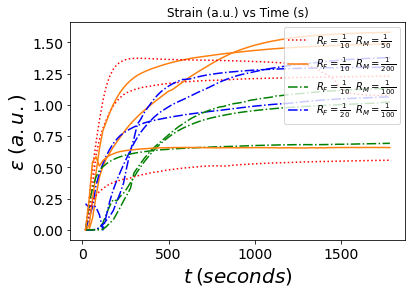

In [58]:

#Plot Strain vs Time

fig = plt.figure()
ax1 = fig.add_subplot(111)
#temperature = times[0:len(Times_List)]

Legend_Used = []

for i in range(len(List_folder)):
#for i in [7]:
    print(List_folder[i])
    if List_Legend[i] in Legend_Used:
        ax1.plot(Times_List[i], Strain_Abs[i], List_Colors[i])
    elif i == 10:
        ax1.plot(Times_List[i], Strain_Abs[i], List_Colors[i])
    else:
        ax1.plot(Times_List[i], Strain_Abs[i], List_Colors[i], label=List_Legend[i])
        Legend_Used.append(List_Legend[i])
plt.title('Strain (a.u.) vs Time (s)')
plt.ylabel('$\epsilon \; (a.u.)$',fontsize=ftsz)
plt.xlabel('$t \: (seconds)$',fontsize=ftsz)
plt.legend(loc="upper right")
plt.tick_params(axis='both', which='major', labelsize=tcksz)

plt.savefig(base + '//ProcessingStrainRate_Files//Graphs//New_Strain_vs_t.png',dpi="figure",format="png",bbox_inches='tight')

plt.show()

In [31]:
sheet = pd.read_csv(List_folder[0]+"//Results//MattiaRep.csv",header=None,index_col=0)
time = sheet.loc["Time (s)"][0:89]
area = sheet.loc["pixels"][0:89]

In [22]:
# DEFUNCT
# Plot Area vs Time for Dr. Mattia

for i in range(len(List_folder)):
#     sheet = pd.read_csv(List_folder[i]+"//Results//MattiaRep.csv")
#     plt.plot(sheet.loc["Time (s)"][0:89],sheet.loc["pixels"][0:89])
    
#    sheet = pd.read_csv(List_folder[0]+"//Results//MattiaRep.csv",header=None,index_col=0)
    sheet = pd.read_csv(List_folder[i]+"//Results//MattiaRep.csv",header=None,index_col=0)
#time = sheet.loc["Time (s)"][0:89]
#area = sheet.loc["pixels"][0:89]
    plt.plot(sheet.loc["Time (s)"][0:89],sheet.loc["pixels"][0:89])
    plt.title('Area (number of pixels) vs Time (s)')
    plt.ylabel('number of pixels (a.u.)',fontsize=ftsz)
    plt.xlabel('$t \: (seconds)$',fontsize=ftsz)
    plt.tick_params(axis='both', which='major', labelsize=tcksz)
    plt.savefig(List_folder[i] + '//Results//'+ File_Legend[i]+' Pixels_vs_t.png',dpi="figure",format="png",bbox_inches='tight')
    plt.clf()
#plt.show()

# fig = plt.figure()
# ax1 = fig.add_subplot(111)
# #temperature = times[0:len(Times_List)]

# Legend_Used = []

# for i in range(len(List_folder)):
#     if List_Legend[i] in Legend_Used:
#         ax1.plot(Times_List[i], Strain_List[i], List_Colors[i])
#     elif i == 10:
#         ax1.plot(Times_List[i], Strain_List[i], List_Colors[i])
#     else:
#         ax1.plot(Times_List[i], Strain_List[i], List_Colors[i], label=List_Legend[i])
#         Legend_Used.append(List_Legend[i])
# plt.title('Normalized Strain (a.u.) vs Time (s)')
# plt.ylabel('$\epsilon/\epsilon_{max} \; (a.u.)$',fontsize=ftsz)
# plt.xlabel('$t \: (seconds)$',fontsize=ftsz)
# plt.legend(loc="upper right")
# plt.tick_params(axis='both', which='major', labelsize=tcksz)

# plt.savefig(base + '//ProcessingStrainRate_Files//Graphs//Normalized_Strain_vs_t.png',dpi="figure",format="png",bbox_inches='tight')

# plt.show()

<Figure size 432x288 with 0 Axes>

In [23]:
# DEFUNCT
# Plot Area vs Time for Dr. Mattia

for i in range(len(List_folder)):
#     sheet = pd.read_csv(List_folder[i]+"//Results//MattiaRep.csv")
#     plt.plot(sheet.loc["Time (s)"][0:89],sheet.loc["pixels"][0:89])
    
#    sheet = pd.read_csv(List_folder[0]+"//Results//MattiaRep.csv",header=None,index_col=0)
    sheet = pd.read_csv(List_folder[i]+"//Results//MattiaRep.csv",header=None,index_col=0)
#time = sheet.loc["Time (s)"][0:89]
#area = sheet.loc["pixels"][0:89]
    plt.plot(sheet.loc["Time (s)"][0:89],0.0429*sheet.loc["pixels"][0:89])
    plt.title('Area (microns^2) vs Time (s)')
    plt.ylabel('Area ${\mu m}^2$',fontsize=ftsz)
    plt.xlabel('$t \: (seconds)$',fontsize=ftsz)
    plt.tick_params(axis='both', which='major', labelsize=tcksz)
    plt.savefig(base + '//ProcessingStrainRate_Files//MattiaWork//'+ File_Legend[i]+' Microns2_vs_t.png',dpi="figure",format="png",bbox_inches='tight')
    plt.clf()
#plt.show()

# fig = plt.figure()
# ax1 = fig.add_subplot(111)
# #temperature = times[0:len(Times_List)]

# Legend_Used = []

# for i in range(len(List_folder)):
#     if List_Legend[i] in Legend_Used:
#         ax1.plot(Times_List[i], Strain_List[i], List_Colors[i])
#     elif i == 10:
#         ax1.plot(Times_List[i], Strain_List[i], List_Colors[i])
#     else:
#         ax1.plot(Times_List[i], Strain_List[i], List_Colors[i], label=List_Legend[i])
#         Legend_Used.append(List_Legend[i])
# plt.title('Normalized Strain (a.u.) vs Time (s)')
# plt.ylabel('$\epsilon/\epsilon_{max} \; (a.u.)$',fontsize=ftsz)
# plt.xlabel('$t \: (seconds)$',fontsize=ftsz)
# plt.legend(loc="upper right")
# plt.tick_params(axis='both', which='major', labelsize=tcksz)

# plt.savefig(base + '//ProcessingStrainRate_Files//Graphs//Normalized_Strain_vs_t.png',dpi="figure",format="png",bbox_inches='tight')

# plt.show()

<Figure size 432x288 with 0 Axes>

In [24]:
# DEFUNCT
# Plot the normalized strain vs normalized energy (J/L)

# fig = plt.figure(figsize=(8,6))
# ax1 = fig.add_subplot(111)

# Legend_Used = []

# #for i in [11]:
# for i in range(len(List_folder)):
#     if List_Legend[i] in Legend_Used:
#         ax1.plot(Energy_List[i][0:len(Strain_List[i])],Strain_List[i], List_Colors[i])
#     else:
#         ax1.plot(Energy_List[i][0:len(Strain_List[i])],Strain_List[i], List_Colors[i], label=List_Legend[i])
#         Legend_Used.append(List_Legend[i])
# #plt.title('N. Strain (a.u.) vs N. Total Energy Consumption (J)')
# plt.ylabel('$\epsilon/\epsilon_{max} \; (a.u.)$',fontsize=ftsz)
# plt.xlabel('$E/E_{max} \: (a.u.)$',fontsize=ftsz)
# plt.legend(loc="upper right")
# plt.tick_params(axis='both', which='major', labelsize=tcksz)

# plt.savefig(base + '//ProcessingStrainRate_Files//Graphs//Normalized_ep_vs_E_v2.png',dpi="figure",format="png",bbox_inches='tight')

# plt.show()

In [25]:
# Plot the normalized strain rate vs normalized energy consumption rate

# fig = plt.figure(figsize=(8,6))
# ax1 = fig.add_subplot(111)
# #print(len(StrainRate_List[0]))
# #print(len(EnergyRate_List[0]))



# for i in range(len(List_folder)):
#     ax1.scatter(EnergyRate_List[i][0:len(StrainRate_List[i])], StrainRate_List[i], s=10, c=Times_List[i])
# plt.title('Normalized Strain Rate (a.u.) vs Normalized Energy Consumption Rate (J/mL/s)')
# plt.ylabel('$\dot \epsilon/ \dot \epsilon_{max} \; (a.u.)$',fontsize=ftsz)
# plt.xlabel('$\dot E/\dot E_{max} \: (a.u.)$',fontsize=ftsz)
# plt.tick_params(axis='both', which='major', labelsize=tcksz)
# plt.savefig(base + '//ProcessingStrainRate_Files//Graphs//Normalized_epR_vs_ER_.png',dpi="figure",format="png",bbox_inches='tight')

# plt.show()

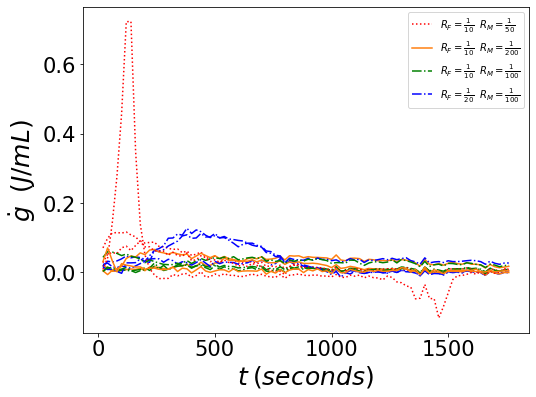

In [26]:
# Plot the energy consumption rate (J/L/s) vs time. 

fig = plt.figure(figsize=(8,6))
ax1 = fig.add_subplot(111)
#temperature = times[0:len(Times_List)]

Legend_Used = []

#for i in [0,4,6,11]:
for i in range(len(List_folder)):
    if i == 10:
        ax1.plot(Times_List[i][0:88], EnergyRate_List[i], List_Colors[i])
    elif List_Legend[i] in Legend_Used:
        ax1.plot(Times_List[i-1][0:88], EnergyRate_List[i], List_Colors[i])
    else:
        ax1.plot(Times_List[i][0:88], EnergyRate_List[i], List_Colors[i], label=List_Legend[i])
        Legend_Used.append(List_Legend[i])
    
    #ax1.plot(Times_List[i], DF_Energy_List[i].iloc[1,0:89], c=List_Colors[i], marker = List_Style[i])
#plt.title('Energy Consumption Rate vs Time (s)')
plt.legend(loc="upper right")
plt.ylabel('$\dot g \; \; (J/mL)$',fontsize=ftsz)
plt.xlabel('$t \: (seconds)$',fontsize=ftsz)
#plt.ylim(-0.01,0.1)
plt.tick_params(axis='both', which='major', labelsize=tcksz)

plt.savefig(base + '//ProcessingStrainRate_Files//Graphs//ER_vs_t_RAW.png',dpi="figure",format="png",bbox_inches='tight')

plt.show()

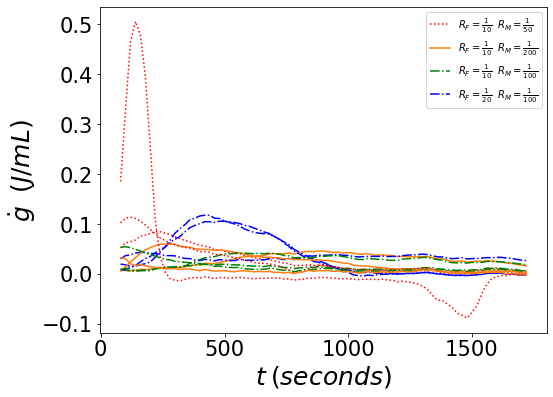

In [27]:
# Plot the smoothed energy consumption rate (J/L/s) vs time. This uses a simple moving average to smooth
# The Energy measurements, which are then converted into timelike measurements

fig = plt.figure(figsize=(8,6))
ax1 = fig.add_subplot(111)
#temperature = times[0:len(Times_List)]

Legend_Used = []

#for i in [0,4,6,11]:
for i in range(len(List_folder)):
    if i == 10:
        ax1.plot(Times_List[i][3:86], Smooth1_EnergyRate_List[i], List_Colors[i])
    elif List_Legend[i] in Legend_Used:
        ax1.plot(Times_List[i-1][3:86], Smooth1_EnergyRate_List[i], List_Colors[i])
    else:
        ax1.plot(Times_List[i][3:86], Smooth1_EnergyRate_List[i], List_Colors[i], label=List_Legend[i])
        Legend_Used.append(List_Legend[i])
    
    #ax1.plot(Times_List[i], DF_Energy_List[i].iloc[1,0:89], c=List_Colors[i], marker = List_Style[i])
#plt.title('Energy Consumption Rate vs Time (s)')
plt.legend(loc="upper right")
plt.ylabel('$\dot g \; \; (J/mL)$',fontsize=ftsz)
plt.xlabel('$t \: (seconds)$',fontsize=ftsz)
#plt.ylim(-0.01,0.1)
plt.tick_params(axis='both', which='major', labelsize=tcksz)

#plt.savefig(base + '//ProcessingStrainRate_Files//Graphs//_ER_vs_t.png',dpi="figure",format="png",bbox_inches='tight')

plt.show()

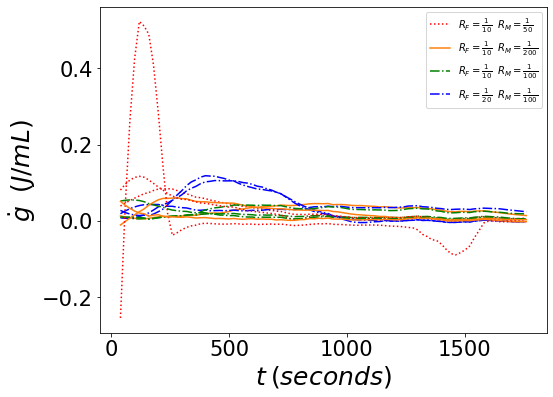

In [28]:
# Plot the smoothed energy consumption rate (J/L/s) vs time. This uses Savitzky-Golay filter to smooth
# The Energy measurements, which are then converted into timelike measurements

fig = plt.figure(figsize=(8,6))
ax1 = fig.add_subplot(111)
#temperature = times[0:len(Times_List)]

Legend_Used = []

#for i in [0,4,6,11]:
for i in range(len(List_folder)):
    if i == 10:
        ax1.plot(Times_List[i][1:88], Smooth2_EnergyRate_List[i], List_Colors[i])
    elif List_Legend[i] in Legend_Used:
        ax1.plot(Times_List[i-1][1:88], Smooth2_EnergyRate_List[i], List_Colors[i])
    else:
        ax1.plot(Times_List[i][1:88], Smooth2_EnergyRate_List[i], List_Colors[i], label=List_Legend[i])
        Legend_Used.append(List_Legend[i])
    
    #ax1.plot(Times_List[i], DF_Energy_List[i].iloc[1,0:89], c=List_Colors[i], marker = List_Style[i])
#plt.title('Energy Consumption Rate vs Time (s)')
plt.legend(loc="upper right")
plt.ylabel('$\dot g \; \; (J/mL)$',fontsize=ftsz)
plt.xlabel('$t \: (seconds)$',fontsize=ftsz)
#plt.ylim(-0.01,0.1)
plt.tick_params(axis='both', which='major', labelsize=tcksz)

plt.savefig(base + '//ProcessingStrainRate_Files//Graphs//ER_vs_t_SG.png',dpi="figure",format="png",bbox_inches='tight')

plt.show()

2022_3_13_Anthony//3-13-2022//0,6_F-0,12_M-3
2022_1_31
2022_2_25
2022_1_28
2022_3_13_Anthony//3-13-2022//0,6_F-0,12_M-1
2022_3_13_Anthony//3-13-2022//0,6_F-0,12_M-2
2022_3_13_Anthony//3-13-2022//1,2 F-0,06 M-1
2022_3_13_Anthony//3-13-2022//1,2 F-0,12 M-1
2022_3_15_Anthony//1,2 F-0,24 M-1
2022_3_15_Anthony//1,2 F-0,24 M-2
2022_4_16
2023_2_03//fascin


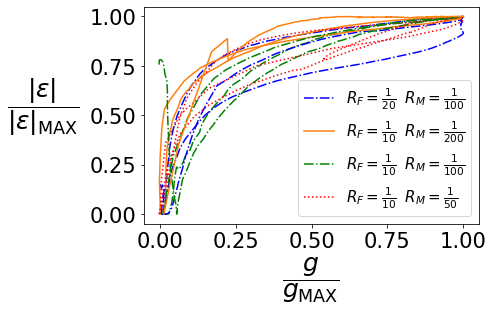

In [29]:
# Plot the normalized strain vs normalized total energy consumption (J/L).

fig = plt.figure()
ax1 = fig.add_subplot(111)
Legend_Used = []

# Problem datasets: [1,2,3,7?,9?,11?]

for i in Ordered_Folders:#range(len(List_folder)):
    print(List_folder[i])
    if i == 10:
        ax1.plot(Energy_ListN[i], Strain_ListN[i][0:len(Energy_ListN[i])], List_Colors[i])
    elif List_Legend[i] in Legend_Used:
        ax1.plot(Energy_ListN[i], Strain_ListN[i][0:len(Energy_ListN[i])], List_Colors[i])
    else:
        ax1.plot(Energy_ListN[i], Strain_ListN[i][0:len(Energy_ListN[i])], List_Colors[i], label=List_Legend[i])
        Legend_Used.append(List_Legend[i])
    
    #ax1.scatter(Energy_List[i][0:len(Strain_List[i])],np.absolute(Strain_List[i]), s=10, c='b', marker=".")
    #ax1.plot(Energy_List[i][0:len(Strain_List[i])],Strain_List[i], c='b', )
#plt.title('Normalized Strain vs Normalized Total Energy Consumption ')
plt.ylabel(r'$\dfrac{|\epsilon|}{{|\epsilon|}_\mathrm{MAX}} $',fontsize=ftsz,rotation=0)
plt.xlabel(r'$\dfrac{g}{g_\mathrm{MAX}}$',fontsize=ftsz)
plt.tick_params(axis='both', which='major', labelsize=tcksz)
#plt.xscale('log')
#plt.yscale('log')
ax1.yaxis.set_label_coords(-0.3,0.4)
plt.legend(loc="lower right",prop={'size': 15})
plt.savefig(base + '//ProcessingStrainRate_Files//Graphs//NStrain_v_Ng_v2.png',dpi="figure",format="png",bbox_inches='tight')

plt.show()

2022_3_13_Anthony//3-13-2022//0,6_F-0,12_M-3
2022_1_31
2022_2_25
2022_1_28
2022_3_13_Anthony//3-13-2022//0,6_F-0,12_M-1
2022_3_13_Anthony//3-13-2022//0,6_F-0,12_M-2
2022_3_13_Anthony//3-13-2022//1,2 F-0,06 M-1
2022_3_13_Anthony//3-13-2022//1,2 F-0,12 M-1
2022_3_15_Anthony//1,2 F-0,24 M-1
2022_3_15_Anthony//1,2 F-0,24 M-2
2022_4_16
2023_2_03//fascin


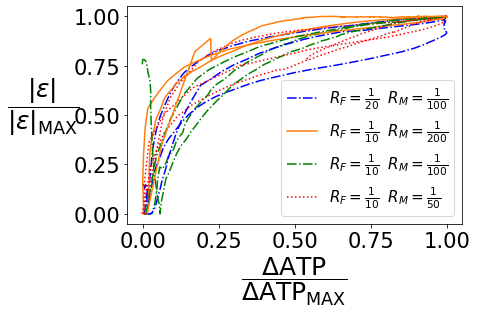

In [30]:
# Plot the normalized strain vs normalized total energy consumption (J/L).

fig = plt.figure()
ax1 = fig.add_subplot(111)
Legend_Used = []

# Problem datasets: [1,2,3,7?,9?,11?]

for i in Ordered_Folders:#range(len(List_folder)):
    print(List_folder[i])
    if i == 10:
        ax1.plot(Energy_ListN[i], Strain_ListN[i][0:len(Energy_ListN[i])], List_Colors[i])
    elif List_Legend[i] in Legend_Used:
        ax1.plot(Energy_ListN[i], Strain_ListN[i][0:len(Energy_ListN[i])], List_Colors[i])
    else:
        ax1.plot(Energy_ListN[i], Strain_ListN[i][0:len(Energy_ListN[i])], List_Colors[i], label=List_Legend[i])
        Legend_Used.append(List_Legend[i])
    
    #ax1.scatter(Energy_List[i][0:len(Strain_List[i])],np.absolute(Strain_List[i]), s=10, c='b', marker=".")
    #ax1.plot(Energy_List[i][0:len(Strain_List[i])],Strain_List[i], c='b', )
#plt.title('Normalized Strain vs Normalized Total Energy Consumption ')
plt.ylabel(r'$\dfrac{|\epsilon|}{{|\epsilon|}_\mathrm{MAX}} $',fontsize=ftsz,rotation=0)
plt.xlabel(r'$\dfrac{\Delta \mathrm{ATP}}{\Delta \mathrm{ATP}_\mathrm{MAX}}$',fontsize=ftsz)
plt.tick_params(axis='both', which='major', labelsize=tcksz)
#plt.xscale('log')
#plt.yscale('log')
ax1.yaxis.set_label_coords(-0.25,0.4)
plt.legend(loc="lower right",prop={'size': 15})

plt.savefig(base + '//ProcessingStrainRate_Files//Graphs//NStrain_v_N NADH_v2.png',dpi="figure",format="png",bbox_inches='tight')

plt.show()

In [31]:
# Make a max_strain scatter plot:

Max_Strain = []
Max_EC = []
Max_EC_Rate = []

#Modified file 9 directly to allow computation of boxplot diagrams, may need to change
#print(DF_Strain_List[9].iloc[0])

for i in range(len(List_folder)):
    if (i == 9):
        Strains = list(DF_Strain_List[i].iloc[0][0:59])
        Strain = np.min(Strains)
        Max_Strain.append(-1.0*Strain)
    else:
        Strains = list(DF_Strain_List[i].iloc[0])
        Strain = np.min(Strains)
        Max_Strain.append(-1.0*Strain)
    
    #Process Energy 
    Energy = list(DF_Energy_List[i].iloc[0])
    Energy_Max = np.max(Energy)
    Max_EC.append(Energy_Max)
    
    #Process Energy Rate -- Uses Savitsky-Golay Algorithm
    EnergyRate = list(Smooth2_EnergyRate_List[i])
    EnergyRate_Max = np.max(EnergyRate)
    Max_EC_Rate.append(EnergyRate_Max)

#print(np.mean(Max_Strain))
#print(np.std(Max_Strain))

In [32]:
# # Make boxplot code for Strain, EnergyConsumption, List of decay exponents, and modulus of maximum strain and energy.:
# def unique(list1):
#     x = np.array(list1)
#     return np.unique(list1)

# list(unique(Myosin_Conditions))
# #Myosin_Conditions.index(0.06)

# #Pull out index positions for all myosin molar ratios equalling 0.06
# Position_List6 = [i for i, e in enumerate(Myosin_Conditions) if e == 0.06]
# print(Position_List6)

# #Pull out index positions for all myosin molar ratios equalling 0.12
# Position_List12 = [i for i, e in enumerate(Myosin_Conditions) if e == 0.12]

# #Pull out index positions for all myosin molar ratios equalling 0.24
# Position_List24 = [i for i, e in enumerate(Myosin_Conditions) if e == 0.24]

# # Create optional list to eliminate positions we'll use.
# Eliminate_List = [i for i, e in enumerate(Fascin_Conditions) if e == '2.4']

# Position_List12_Reduced = [i for i in Position_List12 if i not in Eliminate_List]

# #Create List for Box Plot with R_M = 1/200
# Box_List6 = []
# for i in Position_List6:
#     Box_List6.append(Max_Strain[i])

# #Create List for Box Plot with R_M = 1/100
# Box_List12 = []
# for i in Position_List12_Reduced:
#     Box_List12.append(Max_Strain[i])    

# #Create List for Box Plot with R_M = 1/50
# Box_List24 = []
# for i in Position_List24:
#     Box_List24.append(Max_Strain[i])
    
# #Create List for Box Plot with R_M = 1/100, R_F = 1/20
# Box_ListF = []
# for i in Eliminate_List:
#     Box_ListF.append(Max_Strain[i])

# #data = {'0.06': Box_List6, '0.12': Box_List12, '0.24': Box_List24}

# # Create the pandas DataFrame with column name is provided explicitly
# #df = pd.DataFrame(data, columns=['Numbers'])
# #Now do the same for strain rate:

# #Create List for Box Plot with R_M = 1/200
# Box_List6_EC = []
# for i in Position_List6:
#     Box_List6_EC.append(Max_EC[i])

# #Create List for Box Plot with R_F = 1/100
# Box_List12_EC = []
# for i in Position_List12_Reduced:
#     Box_List12_EC.append(Max_EC[i])    

# #Create List for Box Plot with R_F = 1/10
# Box_List24_EC = []
# for i in Position_List24:
#     Box_List24_EC.append(Max_EC[i]) 
    
# #Create List for Box Plot with R_F = 1/20
# Box_ListF_EC = []
# for i in Eliminate_List:
#     Box_ListF_EC.append(Max_EC[i]) 
    
# #print(Box_List24_EC)

# # Make list of fitted exponents too
# Exp_List6 = []
# for i in Position_List6:
#     Exp_List6.append(FitExponent_List[i])

# #Create List for fitted exponents
# Exp_List12 = []
# for i in Position_List12_Reduced:
#     Exp_List12.append(FitExponent_List[i])    

# #Create List for fitted exponents
# Exp_List24 = []
# for i in Position_List24:
#     Exp_List24.append(FitExponent_List[i])
    
# # Create List for fascin comparison
# Exp_List_F20 = []
# for i in Eliminate_List:
#     Exp_List_F20.append(FitExponent_List[i]) 
    

# # Create a list for max strain/max energy
# S_div_e6 = []
# for i in Position_List6:
#     S_div_e6.append(np.abs(Max_Strain[i])/Max_EC[i])
    
# S_div_e12 = []
# for i in Position_List12_Reduced:
#     S_div_e12.append(np.abs(Max_Strain[i])/Max_EC[i])
    
# S_div_e24 = []
# for i in Position_List24:
#     S_div_e24.append(np.abs(Max_Strain[i])/Max_EC[i])
    
# S_div_eF = []
# for i in Eliminate_List:
#     S_div_eF.append(np.abs(Max_Strain[i])/Max_EC[i])

In [33]:
# # Make boxplot code for EnergyConsumptionRate:
# Box6_ECR = []
# for i in Position_List6:
#     Box6_ECR.append(Max_EC_Rate[i])

# #Create List for Box Plot with R_F = 1/100
# Box12_ECR = []
# for i in Position_List12_Reduced:
#     Box12_ECR.append(Max_EC_Rate[i])    

# #Create List for Box Plot with R_F = 1/10
# Box24_ECR = []
# for i in Position_List24:
#     Box24_ECR.append(Max_EC_Rate[i]) 
    
# #Create List for Box Plot with R_F = 1/20
# BoxF_ECR = []
# for i in Eliminate_List:
#     BoxF_ECR.append(Max_EC_Rate[i]) 

In [34]:
# # Make list of fitted exponents for absolute values
# Exp_abs_List6 = []
# for i in Position_List6:
#     Exp_abs_List6.append(-1000.0/FitExponent_Abs[i])

# #Create List for fitted exponents
# Exp_abs_List12 = []
# for i in Position_List12_Reduced:
#     Exp_abs_List12.append(-1000.0/FitExponent_Abs[i])    

# #Create List for fitted exponents
# Exp_abs_List24 = []
# for i in Position_List24:
#     Exp_abs_List24.append(-1000.0/FitExponent_Abs[i])
    
# # Create List for fascin comparison
# Exp_abs_List_F20 = []
# for i in Eliminate_List:
#     Exp_abs_List_F20.append(-1000.0/FitExponent_Abs[i])

In [35]:
# # Don't use the below code unless you know what you are doing; this isn't meant to be used carelessly
# Max_EC_Old = []
# Strains_Old = []
# Strain_Div_EC_Old = []
# for i in range(0,3):
#     Max_EC_Old.append(Max_EC[i])
#     Strains_Old.append(Max_Strain[i])
#     Strain_Div_EC_Old.append(Max_Strain[i]/Max_EC[i])
    
    
# Max_EC_New = []
# Strains_New = []
# Strain_Div_EC_New = []
# for i in range(3,6):
#     Max_EC_New.append(Max_EC[i])
#     Strains_New.append(Max_Strain[i])
#     Strain_Div_EC_New.append(Max_Strain[i]/Max_EC[i])
    
    
# print(len(Max_EC_Old))
# print(len(Max_EC_New))

In [36]:
# Make a reduced exponent list:

# FitExponent_List_Reduced = [i for i in FitExponent_List if FitExponent_List.index(i) not in Eliminate_List]
# Myosin_Conditions_Reduced = [e for i, e in enumerate(Myosin_Conditions) if i not in Eliminate_List]
#print(Myosin_Conditions_Reduced)

In [37]:
# # Create dataset that matches the 
# Seaborn_Strain = pd.DataFrame({'0.06': pd.Series(Box_List6), '0.12': pd.Series(Box_List12), '0.24': pd.Series(Box_List24)})
# Seaborn_Energy = pd.DataFrame({'$R_F= 1/20$ \n $R_M = 1/100$': pd.Series(Box_ListF_EC), '$1/10$ \n $1/200$': pd.Series(Box_List6_EC), 
#                                '$1/10$ \n $1/100$': pd.Series(Box_List12_EC),'$1/10$ \n $1/50$': pd.Series(Box_List24_EC)})
# Seaborn_EnergyR = pd.DataFrame({'$R_F= 1/20$ \n $R_M = 1/100$': pd.Series(BoxF_ECR), '$1/10$ \n $1/200$': pd.Series(Box6_ECR), 
#                                '$1/10$ \n $1/100$': pd.Series(Box12_ECR),'$1/10$ \n $1/50$': pd.Series(Box24_ECR)})

# Seaborn_Fitting = pd.DataFrame({'$R_M$ = 1/200': pd.Series(Exp_List6), '$R_M$ = 1/100': pd.Series(Exp_List12), 
#                                 '$R_M$ = 1/50': pd.Series(Exp_List24)})
# Seaborn_Fascin = pd.DataFrame({'$R_F$ = 1/10': pd.Series(Exp_List12), '$R_F$ = 1/20': pd.Series(Exp_List_F20)})
# # Seaborn_Division = pd.DataFrame({'$R_M$ = 1/200': pd.Series(S_div_e6), '$R_M$ = 1/100': pd.Series(S_div_e12), 
# #'$R_M$ = 1/50': pd.Series(S_div_e24)})
# # Seaborn_Division_F = pd.DataFrame({'$R_F$ = 1/10': pd.Series(S_div_e12), '$R_F$ = 1/20': pd.Series(S_div_eF)})

In [38]:
# Seaborn_Abs_Fitting = pd.DataFrame({'$R_F= 1/20$ \n $R_M = 1/100$': pd.Series(Exp_abs_List_F20),
#                                    '$1/10$ \n $1/200$': pd.Series(Exp_abs_List6), 
#                                     '$1/10$ \n $1/100$': pd.Series(Exp_abs_List12), 
#                                     '$1/10$ \n $1/50$': pd.Series(Exp_abs_List24)})
# Seaborn_Abs_Strain = pd.DataFrame({'$R_F= 1/20$ \n $R_M = 1/100$': pd.Series(Box_ListF),
#                                    '$1/10$ \n $1/200$': pd.Series(Box_List6), 
#                                     '$1/10$ \n $1/100$': pd.Series(Box_List12), 
#                                     '$1/10$ \n $1/50$': pd.Series(Box_List24)})
# Seaborn_Strain_Div_E = pd.DataFrame({'$R_F= 1/20$ \n $R_M = 1/100$': pd.Series(S_div_eF),
#                                    '$1/10$ \n $1/200$': pd.Series(S_div_e6), 
#                                     '$1/10$ \n $1/100$': pd.Series(S_div_e12), 
#                                     '$1/10$ \n $1/50$': pd.Series(S_div_e24)})

# # Calculate average Time Constant
# TCons = []
# listy = [Exp_abs_List_F20,Exp_abs_List6,Exp_abs_List12,Exp_abs_List24]
# for i in range(0,4):
#     print(i)
#     for j in range(0,3):
#         TCons.append(curr_listy[j])


# # Tau here is measured as the exponential decay constant, from a fitted exponential power law. Good reason
# # to include exponential fits in supplementary information!
# Tavg = np.mean(TCons)
# Tstd = np.std(TCons)
# print(Tavg)
# print(Tstd)
# print(listy)

In [39]:
# Seaborn_TestAcross_E = pd.DataFrame({"Old": pd.Series(Max_EC_Old),"New": pd.Series(Max_EC_New)})
# Seaborn_TestAcross_Strain = pd.DataFrame({"Old": pd.Series(Strains_Old),"New": pd.Series(Strains_New)})
# Seaborn_Test_Moduli = pd.DataFrame({"Old": pd.Series(Strain_Div_EC_Old),"New": pd.Series(Strain_Div_EC_New)})


# #Create pair_list
# pairs_list = [('$R_F= 1/20$ \n $R_M = 1/100$','$1/10$ \n $1/200$'),
#               ('$R_F= 1/20$ \n $R_M = 1/100$','$1/10$ \n $1/100$'),
#               ('$R_F= 1/20$ \n $R_M = 1/100$','$1/10$ \n $1/50$'),
#               ('$1/10$ \n $1/200$','$1/10$ \n $1/100$'),
#               ('$1/10$ \n $1/200$','$1/10$ \n $1/50$'),
#               ('$1/10$ \n $1/100$','$1/10$ \n $1/50$')]

In [40]:
# Make the Max energy scatter plot:

# #print(DataPlot)
# y = Max_EC
# x = Myosin_Conditions

# plt.scatter(x,y)
# #plt.title('Peak Energy/Volume Consumption vs. [Myosin]')
# plt.xlabel("[Myosin] (μM)",fontsize=ftsz)
# plt.ylabel("$\mathrm{MAX}( e/V)$ $\; (J \cdot s^{-1} mL^{-1})$", fontsize=ftsz)
# plt.tick_params(axis='both', which='major', labelsize=tcksz)
# plt.savefig('ProcessingStrainRate_Files\\Graphs\\MAX_e_vs_[Myosin].png',bbox_inches='tight')

# plt.show()

#Notes from Alvarado 8/3/2022:
# Make boxplots for these two plots.
# Use asterisk notation for significance. Denote with star. Find pythonic method.
# Talk to James for these methods.
# Probably run a 1/200 myosin experiment later in the future.
# Make a plot comparing fascin concentrations.
# Add MAX subscript for y-axis labels.
#

In [41]:
# #y = Max_EC 
# #x = Myosin_Conditions

# #plt.scatter(x,y)
# plt.boxplot([Box_List6_EC,Box_List12_EC,Box_List24_EC],positions=[0.6,1.2,2.4])
# #plt.title('Peak Strain vs. [Myosin]')
# plt.xlabel("[Myosin] (μM*$10^{-1}$)",fontsize=ftsz)
# plt.ylabel("$\mathrm{MAX}( e/V)$ $\; (J \cdot s^{-1} mL^{-1})$", fontsize=ftsz)
# plt.tick_params(axis='both', which='major', labelsize=tcksz)
# plt.savefig('ProcessingStrainRate_Files\\Graphs\\BOX_MAX_e_vs_[Myosin].png',bbox_inches='tight')

# plt.show() 

In [42]:
#Make a max strain rate scatter plot

# y = Max_Strain 
# x = Myosin_Conditions

# plt.scatter(x,y)
# #plt.boxplot([Box_List6,Box_List12,Box_List24])
# #plt.title('Peak Strain vs. [Myosin]')
# plt.xlabel("[Myosin] (μM)",fontsize=ftsz)
# plt.ylabel("$\epsilon$",fontsize=ftsz)
# plt.tick_params(axis='both', which='major', labelsize=tcksz)
# plt.savefig('ProcessingStrainRate_Files\\Graphs\\MAX_h_vs_[Myosin].png',bbox_inches='tight')

# plt.show() 

In [43]:
# Make a max strain scatter plot

# y = Max_Strain
# x = Myosin_Conditions

# #plt.scatter(x,y)
# plt.boxplot([Box_List6,Box_List12,Box_List24])
# #plt.title('Peak Strain vs. [Myosin]')
# plt.xlabel("[Myosin] (μM)",fontsize=ftsz)
# plt.ylabel("$\epsilon$",fontsize=ftsz)
# plt.tick_params(axis='both', which='major', labelsize=tcksz)
# plt.savefig('ProcessingStrainRate_Files\\Graphs\\BOX_MAX_h_vs_[Myosin].png',bbox_inches='tight')

# plt.show() 

In [44]:
# # Make the Seaborne box plots, max strain

# # Set palette for boxplot
# sns.set_theme(style="ticks", palette="tab10")

# pairs = [("0.06","0.12"),("0.06","0.24"),("0.12","0.24")]
# print(Box_List24)

# # Load the example tips dataset
# #tips = sns.load_dataset("tips")

# #print(tips)
# #print(tips.iloc[:,1])

# # Draw a nested boxplot to show bills by day and time
# ax = sns.stripplot(data=Seaborn_Strain,jitter=False,s=tcksz)
# annotator = Annotator(ax, pairs, data=Seaborn_Strain)
# annotator.configure(test="t-test_ind")
# annotator.apply_and_annotate()
# #ax.set(ylabel="$\mathrm{MAX} \; \epsilon$", xlabel="[Myosin] (μM)",fontsize=ftsz)
# plt.ylabel("$\epsilon_{\mathrm{MAX}}$ (a.u.)",fontsize=ftsz)
# plt.xlabel("[Myosin] (μM)",fontsize=ftsz)
# plt.tick_params(axis='both', which='major', labelsize=tcksz)

# plt.savefig('ProcessingStrainRate_Files\\Graphs\\BOX_MAX_h_vs_[Myosin].png',bbox_inches='tight')
# plt.show()
# #sns.despine(offset=10, trim=True)

In [45]:
# # Make the Seaborne box plots, max strain

# # Set palette for boxplot
# sns.set_theme(style="ticks", palette="tab10")

# pairs = [('$R_F= 1/20$ \n $R_M = 1/100$','$1/10$ \n $1/200$'),
#               ('$R_F= 1/20$ \n $R_M = 1/100$','$1/10$ \n $1/100$'),
#               ('$R_F= 1/20$ \n $R_M = 1/100$','$1/10$ \n $1/50$'),
#               ('$1/10$ \n $1/200$','$1/10$ \n $1/100$'),
#               ('$1/10$ \n $1/200$','$1/10$ \n $1/50$'),
#               ('$1/10$ \n $1/100$','$1/10$ \n $1/50$')]
# #pairs_list#[('$R_M=$ 0.06 \n $R_F$ = 1.2','0.12 \n 1.2'),('$R_M=$ 0.06 \n $R_F$ = 1.2','0.24 \n 1.2'),('0.12 \n 1.2','0.24 \n 1.2'),('$R_M=$ 0.06 \n $R_F$ = 1.2','0.12 \n 0.6'),('0.12 \n 1.2','0.12 \n 0.6'),('0.24 \n 1.2','0.12 \n 0.6')]
# print(Box_List24)

# # Load the example tips dataset
# #tips = sns.load_dataset("tips")

# #print(tips)
# #print(tips.iloc[:,1])

# # Draw a nested boxplot to show bills by day and time
# ax = sns.stripplot(data=Seaborn_Abs_Strain,jitter=False,s=tcksz)
# # annotator = Annotator(ax, pairs, data=Seaborn_Abs_Strain)
# # annotator.configure(test="t-test_ind")
# # annotator.apply_and_annotate()
# #ax.set(ylabel="$\mathrm{MAX} \; \epsilon$", xlabel="[Myosin] (μM)",fontsize=ftsz)
# plt.ylabel("$|\epsilon|_{\mathrm{MAX}}$ ",fontsize=ftsz,rotation=0)
# #plt.xlabel("[Myosin] (μM)",fontsize=ftsz)
# plt.tick_params(axis='both', which='major', labelsize=tcksz)
# plt.ylim(0.0,1.7)
# ax.yaxis.set_label_coords(-0.2,0.4)
# plt.savefig('ProcessingStrainRate_Files\\Graphs\\BOX_MAX_h_All.png',bbox_inches='tight')
# plt.show()
# #sns.despine(offset=10, trim=True)

In [47]:
# # # Make the seaborne boxplot for max energy consumption

# # Set palette for boxplot
# sns.set_theme(style="ticks", palette="tab10")

# pairs = [('$R_F= 1/20$ \n $R_M = 1/100$','$1/10$ \n $1/100$'),
#               ('$R_F= 1/20$ \n $R_M = 1/100$','$1/10$ \n $1/50$')]
# #pairs_list#[('$R_M=$ 0.06 \n $R_F$ = 1.2','0.12 \n 1.2'),('$R_M=$ 0.06 \n $R_F$ = 1.2','0.24 \n 1.2'),
#           #('0.12 \n 1.2','0.24 \n 1.2'),('$R_M=$ 0.06 \n $R_F$ = 1.2','0.12 \n 0.6'),
#           #('0.12 \n 1.2','0.12 \n 0.6'),('0.24 \n 1.2','0.12 \n 0.6')]

# #pairs = [('$R_M=$ 0.06 \n $R_F$ = 1.2','0.24 \n 1.2'),
# #         ('$R_M=$ 0.06 \n $R_F$ = 1.2','0.12 \n 0.6')]

# # Load the example tips dataset
# #tips = sns.load_dataset("tips")

# #print(tips)
# #print(tips.iloc[:,1])

# # Draw a nested boxplot to show bills by day and time
# ax = sns.stripplot(data=Seaborn_Energy,jitter=False,s=tcksz)
# annotator = Annotator(ax, pairs, data=Seaborn_Energy)
# annotator.configure(test="t-test_ind")
# annotator.apply_and_annotate()
# #ax.set(ylabel="$\mathrm{MAX}\; e \: \: (J)$", xlabel="[Myosin] (μM)")
# plt.ylabel(r"$g_{\mathrm{MAX}}$" 
#            "\n"
#            "$\mathrm{(J/L)}$",fontsize=ftsz,rotation=0)
# #plt.xlabel("Conditions",fontsize=ftsz)
# plt.tick_params(axis='both', which='major', labelsize=tcksz)
# ax.yaxis.set_label_coords(-0.15,0.4)

# plt.savefig('ProcessingStrainRate_Files\\Graphs\\BOX_MAX_g.png',bbox_inches='tight')
# plt.show()
# #sns.despine(offset=10, trim=True)

In [48]:
# # # Make the seaborne boxplot for max energy consumption

# # Set palette for boxplot
# sns.set_theme(style="ticks", palette="tab10")

# pairs = [('$R_F= 1/20$ \n $R_M = 1/100$','$1/10$ \n $1/200$'),
#               ('$R_F= 1/20$ \n $R_M = 1/100$','$1/10$ \n $1/100$'),
#               ('$R_F= 1/20$ \n $R_M = 1/100$','$1/10$ \n $1/50$'),
#               ('$1/10$ \n $1/200$','$1/10$ \n $1/100$'),
#               ('$1/10$ \n $1/200$','$1/10$ \n $1/50$'),
#               ('$1/10$ \n $1/100$','$1/10$ \n $1/50$')]
# #pairs = [('$R_F= 1/20$ \n $R_M = 1/100$','$1/10$ \n $1/100$'),
# #              ('$R_F= 1/20$ \n $R_M = 1/100$','$1/10$ \n $1/50$')]
# #pairs_list#[('$R_M=$ 0.06 \n $R_F$ = 1.2','0.12 \n 1.2'),('$R_M=$ 0.06 \n $R_F$ = 1.2','0.24 \n 1.2'),
#           #('0.12 \n 1.2','0.24 \n 1.2'),('$R_M=$ 0.06 \n $R_F$ = 1.2','0.12 \n 0.6'),
#           #('0.12 \n 1.2','0.12 \n 0.6'),('0.24 \n 1.2','0.12 \n 0.6')]

# #pairs = [('$R_M=$ 0.06 \n $R_F$ = 1.2','0.24 \n 1.2'),
# #         ('$R_M=$ 0.06 \n $R_F$ = 1.2','0.12 \n 0.6')]

# # Load the example tips dataset
# #tips = sns.load_dataset("tips")

# #print(tips)
# #print(tips.iloc[:,1])

# # Draw a nested boxplot to show bills by day and time
# ax = sns.stripplot(data=Seaborn_EnergyR,jitter=False,s=tcksz)
# annotator = Annotator(ax, pairs, data=Seaborn_EnergyR)
# annotator.configure(test="t-test_ind")
# #annotator.apply_and_annotate()
# #ax.set(ylabel="$\mathrm{MAX}\; e \: \: (J)$", xlabel="[Myosin] (μM)")
# plt.ylabel(r"$\dot g_{\mathrm{MAX}}$" 
#            "\n"
#            "$\mathrm{(J/L/s)}$",fontsize=ftsz,rotation=0)
# plt.ylim(-0.01,0.35)
# #plt.xlabel("Conditions",fontsize=ftsz)
# plt.tick_params(axis='both', which='major', labelsize=20)
# ax.yaxis.set_label_coords(-0.25,0.35)

# plt.savefig('ProcessingStrainRate_Files\\Graphs\\BOX_MAX_gR.png',bbox_inches='tight')
# plt.show()
# #sns.despine(offset=10, trim=True)

In [49]:
# # Manually test the t-test from scipy
# from scipy import stats
# print(stats.ttest_ind(Seaborn_Energy["0.06"],Seaborn_Energy["0.12"]))
# s_b = np.var(Seaborn_Energy["0.06"],ddof=1)
# s_a = np.var(Seaborn_Energy["0.12"],ddof=1)
# m_b = np.mean(Seaborn_Energy["0.06"])
# m_a = np.mean(Seaborn_Energy["0.12"])

# t_stat = (m_a - m_b)/(np.sqrt(2*s_b**2+2*s_a**2)/4)/np.sqrt(2/3)
# print(s_b)
# print(s_a)
# print(t_stat)

In [50]:
# mpl.rc_file_defaults()

# FitExponent_List_Comp = [-1.0*i for i in FitExponent_List]

# # Make a scatterplot of various exponential fitting parameters

# y = FitExponent_List_Comp
# x = Myosin_Conditions

# plt.scatter(x,y)
# #plt.boxplot([Box_List6_EC,Box_List12_EC,Box_List24_EC],positions=[0.6,1.2,2.4])
# #plt.title('Peak Strain vs. [Myosin]')
# plt.xlabel("[Myosin] (μM)",fontsize=ftsz)
# plt.ylabel("$|b| \; (1/J)$", fontsize=ftsz)
# plt.tick_params(axis='both', which='major', labelsize=tcksz)
# plt.yscale('log')
# plt.savefig('ProcessingStrainRate_Files\\Graphs\\Scatter_ExpFit.png',bbox_inches='tight')

# plt.show() 

In [51]:
# # Make the seaborne boxplot for max energy consumption

# # Set palette for boxplot
# sns.set_theme(style="ticks", palette="tab10")

# pairs = [('$R_M$ = 1/200','$R_M$ = 1/100'),('$R_M$ = 1/200','$R_M$ = 1/50'),('$R_M$ = 1/100','$R_M$ = 1/50')]

# # Load the example tips dataset
# #tips = sns.load_dataset("tips")

# #print(tips)
# #print(tips.iloc[:,1]) 

# # Draw a nested boxplot to show bills by day and time
# ax = sns.stripplot(data=Seaborn_Fitting,jitter=False,s=tcksz)
# annotator = Annotator(ax, pairs, data=Seaborn_Fitting)
# annotator.configure(test="t-test_ind")
# annotator.apply_and_annotate()
# #ax.set(ylabel="$\mathrm{MAX}\; e \: \: (J)$", xlabel="[Myosin] (μM)")
# plt.xlabel("[Myosin] (Molar Ratio to Actin)",fontsize=ftsz)
# plt.ylabel("$b \; (1/J)$", fontsize=ftsz)
# plt.tick_params(axis='both', which='major', labelsize=tcksz)

# plt.savefig('ProcessingStrainRate_Files\\Graphs\\ExpFit.png',bbox_inches='tight')
# plt.show()
# #sns.despine(offset=10, trim=True)

In [54]:
# # Make the seaborne scatterplot for strain time constant

# # Set palette for boxplot
# sns.set_theme(style="ticks", palette="tab10")

# pairs = [('$R_F= 1/20$ \n $R_M = 1/100$','$1/10$ \n $1/50$')]
# #[('$R_F= 1/20$ \n $R_M = 1/100$','$1/10$ \n $1/100$')]
#               #pairs_list#[('$R_M=$ 0.06 \n $R_F$ = 1.2','0.12 \n 1.2'),('$R_M=$ 0.06 \n $R_F$ = 1.2','0.24 \n 1.2'),
#          #('0.12 \n 1.2','0.24 \n 1.2'),('$R_M=$ 0.06 \n $R_F$ = 1.2','0.12 \n 0.6'),
#          #('0.12 \n 1.2','0.12 \n 0.6'),('0.24 \n 1.2','0.12 \n 0.6')]
# print(Seaborn_Abs_Fitting)
# # Load the example tips dataset
# #tips = sns.load_dataset("tips")

# #print(tips)
# #print(tips.iloc[:,1]) 

# # Draw a nested boxplot to show bills by day and time
# ax = sns.stripplot(data=Seaborn_Abs_Fitting,jitter=True,s=tcksz)
# #annotator = Annotator(ax, pairs, data=Seaborn_Abs_Fitting)
# #annotator.configure(test="t-test_ind")
# #annotator.apply_and_annotate()
# #ax.set(ylabel="$\mathrm{MAX}\; e \: \: (J)$", xlabel="[Myosin] (μM)")
# #plt.xlabel("Conditions",fontsize=ftsz)
# plt.ylabel("$τ$ $\mathrm{(s)}$", fontsize=ftsz,rotation=0)
# plt.tick_params(axis='both', which='major', labelsize=tcksz)
# ax.yaxis.set_label_coords(-0.2, 0.5)

# plt.savefig('ProcessingStrainRate_Files\\Graphs\\ExpAbsFit.png',bbox_inches='tight')
# plt.show()
# #sns.despine(offset=10, trim=True)

In [55]:
# # Make the seaborne boxplot for max energy consumption

# # Set palette for boxplot
# sns.set_theme(style="ticks", palette="tab10")

# pairs = [("$R_F$ = 1/10","$R_F$ = 1/20")]

# # Load the example tips dataset
# #tips = sns.load_dataset("tips")

# #print(tips)
# #print(tips.iloc[:,1]) 

# # Draw a nested boxplot
# ax = sns.stripplot(data=Seaborn_Fascin,jitter=True,s=tcksz)
# annotator = Annotator(ax, pairs, data=Seaborn_Fascin)
# annotator.configure(test="t-test_ind")
# annotator.apply_and_annotate()
# #ax.set(ylabel="$\mathrm{MAX}\; e \: \: (J)$", xlabel="[Myosin] (μM)")
# plt.xlabel("[Fascin]",fontsize=ftsz)
# plt.ylabel("$b \; (1/J)$", fontsize=ftsz)
# plt.tick_params(axis='both', which='major', labelsize=tcksz)

# plt.savefig('ProcessingStrainRate_Files\\Graphs\\ExpFit_Fascin.png',bbox_inches='tight')
# plt.show()

In [56]:
# # Create a max strain/ max Energy plot
# # Make the seaborne boxplot for max energy consumption

# # Set palette for boxplot
# sns.set_theme(style="ticks", palette="tab10")

# pairs = [('$R_M$ = 1/200','$R_M$ = 1/100'),('$R_M$ = 1/200','$R_M$ = 1/50'),('$R_M$ = 1/100','$R_M$ = 1/50')]

# # Load the example tips dataset
# #tips = sns.load_dataset("tips")

# #print(tips)
# #print(tips.iloc[:,1]) 

# # Draw a nested boxplot to show bills by day and time
# ax = sns.stripplot(data=Seaborn_Division,jitter=True,s=tcksz)
# annotator = Annotator(ax, pairs, data=Seaborn_Division)
# annotator.configure(test="t-test_ind")
# annotator.apply_and_annotate()
# #ax.set(ylabel="$\mathrm{MAX}\; e \: \: (J)$", xlabel="[Myosin] (μM)")
# plt.xlabel("[Myosin] (Molar Ratio to Actin)",fontsize=ftsz)
# plt.ylabel("$\epsilon_\mathrm{MAX}/e_\mathrm{MAX} \; (1/J)$", fontsize=ftsz)
# plt.tick_params(axis='both', which='major', labelsize=tcksz)

# plt.savefig('ProcessingStrainRate_Files\\Graphs\\StrainDivE_Max.png',bbox_inches='tight')
# plt.show()
# #sns.despine(offset=10, trim=True)

In [57]:
# # Make the seaborne boxplot for max energy consumption

# # Set palette for boxplot
# sns.set_theme(style="ticks", palette="tab10")

# pairs = [("$R_F$ = 1/10","$R_F$ = 1/20")]

# # Load the example tips dataset
# #tips = sns.load_dataset("tips")

# #print(tips)
# #print(tips.iloc[:,1]) 

# # Draw a nested boxplot
# ax = sns.stripplot(data=Seaborn_Division_F,jitter=True,s=tcksz)
# annotator = Annotator(ax, pairs, data=Seaborn_Division_F)
# annotator.configure(test="t-test_ind")
# annotator.apply_and_annotate()
# #ax.set(ylabel="$\mathrm{MAX}\; e \: \: (J)$", xlabel="[Myosin] (μM)")
# plt.xlabel("[Fascin]",fontsize=ftsz)
# plt.ylabel("$\epsilon_\mathrm{MAX}/e_\mathrm{MAX} \; (1/J)$", fontsize=ftsz)
# plt.tick_params(axis='both', which='major', labelsize=tcksz)

# plt.savefig('ProcessingStrainRate_Files\\Graphs\\Div_Fascin.png',bbox_inches='tight')
# plt.show()

In [58]:
# # Make a comparison for the two gels

# # Set palette for boxplot
# sns.set_theme(style="ticks", palette="tab10")

# pairs = [("Old","New")]

# # Load the example tips dataset
# #tips = sns.load_dataset("tips")

# #print(tips)
# #print(tips.iloc[:,1]) 

# # Draw a nested boxplot
# ax = sns.stripplot(data=Seaborn_TestAcross_E,jitter=False,s=tcksz)
# annotator = Annotator(ax, pairs, data=Seaborn_TestAcross_E)
# annotator.configure(test="t-test_ind")
# annotator.apply_and_annotate()
# #ax.set(ylabel="$\mathrm{MAX}\; e \: \: (J)$", xlabel="[Myosin] (μM)")
# #plt.xlabel("",fontsize=ftsz)
# plt.ylabel("$e_\mathrm{MAX} \; (J)$", fontsize=ftsz)
# plt.tick_params(axis='both', which='major', labelsize=tcksz)

# plt.savefig('ProcessingStrainRate_Files\\Graphs\\Max_E_Comparison.png',bbox_inches='tight')
# plt.show()

In [59]:
# # Make a comparison for the two gels

# # Set palette for boxplot
# sns.set_theme(style="ticks", palette="tab10")

# pairs = [("Old","New")]

# # Load the example tips dataset
# #tips = sns.load_dataset("tips")

# #print(tips)
# #print(tips.iloc[:,1]) 

# # Draw a nested boxplot
# ax = sns.stripplot(data=Seaborn_TestAcross_Strain,jitter=False,s=tcksz)
# annotator = Annotator(ax, pairs, data=Seaborn_TestAcross_Strain)
# annotator.configure(test="t-test_ind")
# annotator.apply_and_annotate()
# #ax.set(ylabel="$\mathrm{MAX}\; e \: \: (J)$", xlabel="[Myosin] (μM)")
# #plt.xlabel("",fontsize=ftsz)
# plt.ylabel("$\epsilon_\mathrm{MAX} \; (a.u.)$", fontsize=ftsz)
# plt.tick_params(axis='both', which='major', labelsize=tcksz)

# plt.savefig('ProcessingStrainRate_Files\\Graphs\\Max_Strain_Comparison.png',bbox_inches='tight')
# plt.show()

In [60]:
# # Make a comparison for the two gels

# # Set palette for boxplot
# sns.set_theme(style="ticks", palette="tab10")

# pairs = [("Old","New")]

# # Load the example tips dataset
# #tips = sns.load_dataset("tips")

# #print(tips)
# #print(tips.iloc[:,1]) 

# # Draw a nested boxplot
# ax = sns.stripplot(data=Seaborn_Test_Moduli,jitter=False,s=tcksz)
# annotator = Annotator(ax, pairs, data=Seaborn_Test_Moduli)
# annotator.configure(test="t-test_ind")
# annotator.apply_and_annotate()
# #ax.set(ylabel="$\mathrm{MAX}\; e \: \: (J)$", xlabel="[Myosin] (μM)")
# #plt.xlabel("",fontsize=ftsz)
# plt.ylabel("$\epsilon_\mathrm{MAX}/e_\mathrm{MAX} \; (1/J)$", fontsize=ftsz)
# plt.tick_params(axis='both', which='major', labelsize=tcksz)

# plt.savefig('ProcessingStrainRate_Files\\Graphs\\Moduli_Comparison.png',bbox_inches='tight')
# plt.show()

In [61]:
# # Make the Seaborne box plots, Response Function G_Max = (epsilon_max/g_max)


# # Set palette for boxplot
# sns.set_theme(style="ticks", palette="tab10")

# pairs = pairs_list#[('$R_M=$ 0.06 \n $R_F$ = 1.2','0.12 \n 1.2'),('$R_M=$ 0.06 \n $R_F$ = 1.2','0.24 \n 1.2'),('$R_M=$ 0.06 \n $R_F$ = 1.2','0.12 \n 0.6')]
# print(Box_List24)

# # Load the example tips dataset
# #tips = sns.load_dataset("tips")

# #print(tips)
# #print(tips.iloc[:,1])

# # Draw a nested boxplot to show bills by day and time
# ax = sns.stripplot(data=Seaborn_Strain_Div_E,jitter=False,s=tcksz)
# # annotator = Annotator(ax, pairs, data=Seaborn_Strain_Div_E)
# # annotator.configure(test="t-test_ind")
# # annotator.apply_and_annotate()
# #ax.set(ylabel="$\mathrm{MAX} \; \epsilon$", xlabel="[Myosin] (μM)",fontsize=ftsz)
# plt.ylabel(r"$\dfrac{|\epsilon|_{\mathrm{MAX}}}{g_\mathrm{MAX}}$"
#            "\n"
#            r"$\mathrm{(L/J)}$",fontsize=ftsz,rotation=0)
# ax.yaxis.set_label_coords(-0.2, 0.3)
# #plt.xlabel("Conditions",fontsize=ftsz)
# plt.tick_params(axis='both', which='major', labelsize=tcksz)
# plt.savefig('ProcessingStrainRate_Files\\Graphs\\C_Max_All.png',bbox_inches='tight')
# plt.show()

In [62]:
# # Here we pull out strains and energy points from my lists individually.
# Strain_List = []
# Strain_Abs = []
# Strain_ListN = []
# StrainRate_List = []
# Energy_List = []
# Energy_ListN = []
# Energy_Max = []
# EnergyRate_List = []
# Times_List = []
# SmallTimes_List = []
# Response_Func = []
# Response_Func_Mstr = []

# FitExponent_List = []

# for i in range(len(List_folder)):#
#     Strains = list(DF_Strain_List[i].iloc[0])
#     Strain_Abs.append(np.abs(Strains))
#     StrainsN = [x/np.min(Strains) for x in Strains]
#     Strain_ListN.append(StrainsN)
#     #Strains = Strains/np.min(Strains)
#     #Strain_List.append(-1.0*Strains)
    
#     #Process Strain Rates
#     Strain_Rates = list(DF_Strain_List[i].iloc[1])
#     #Strain_Rates = [-1.0*x/np.min(Strain_Rates) for x in Strain_Rates]
#     StrainRate_List.append(Strain_Rates)
    
#     #Process Energy
#     Energies = list(DF_Energy_List[i].iloc[0])
#     Energies = [x for x in Energies]
#     Energy_List.append(Energies)
#     EnergiesN = [x/np.max(Energies) for x in Energies]
#     Energy_ListN.append(EnergiesN)
#     Energy_Max.append(np.max(Energies))
    
#     #Process Energy Rate
#     Energy_Rates = list(DF_Energy_List[i].iloc[1])
#     #Energy_Rates = [s for s in Energy_Rates]#/np.max(Energy_Rates)
#     EnergyRate_List.append(list(Energy_Rates))
    
#     #Process Time
#     Times = list(DF_Strain_List[i].iloc[2])
#     SmallTimes = [x/1000 for x in Times]
#     Times_List.append(Times)
#     SmallTimes_List.append(SmallTimes)
    
#     Strain_dV_G = np.min(list(DF_Strain_List[i].iloc[0]))/np.max(list(DF_Energy_List[i].iloc[0]))
#     Response_Func.append(Strain_dV_G)
#     Response_Func_Indv = []
#     for j in range(1,len(list(DF_Energy_List[i].iloc[0]))):
#         if (i == 9):
#             x = list(DF_Strain_List[i].iloc[0,0:59])
#             jep = list(DF_Energy_List[i].iloc[0,0:59])
#             if (j <=58):
#                 #Indv_Strain_dV_G = x[j]/jep[j]*np.max(Energies)/np.min(Strains)
#                 Indv_Strain_dV_G = 1/jep[j]*np.max(Energies)*x[j]/np.min(Strains)
#                 Response_Func_Indv.append(Indv_Strain_dV_G)
#             else:
#                 pass
#         else:
#             x = list(DF_Strain_List[i].iloc[0])
#             jep = list(DF_Energy_List[i].iloc[0])
#             #Indv_Strain_dV_G = x[j]/jep[j]*np.max(Energies)/np.min(Strains)
#             Indv_Strain_dV_G = 1/jep[j]*np.max(Energies)*x[j]/np.min(Strains)
#             Response_Func_Indv.append(Indv_Strain_dV_G)
#     Response_Func_Mstr.append(Response_Func_Indv)

In [63]:
# # Plot G as a function of time.

# fig = plt.figure()
# ax1 = fig.add_subplot(111)

# Legend_Used = []

# #for i in [11]:
# for i in Ordered_Folders:#range(len(List_folder)):
#     if List_Legend[i] in Legend_Used:
#         ax1.plot(Energy_ListN[i][3:len(Response_Func_Mstr[i])+1],Response_Func_Mstr[i][2:],List_Colors[i])
#     else:
#         ax1.plot(Energy_ListN[i][3:len(Response_Func_Mstr[i])+1],Response_Func_Mstr[i][2:], List_Colors[i], label=List_Legend[i])
#         Legend_Used.append(List_Legend[i])
# #plt.title('N. Strain (a.u.) vs N. Total Energy Consumption (J)')
# plt.ylabel(r'$\dfrac{|\epsilon|}{g}\cdot \dfrac{g_\mathrm{MAX}}{|\epsilon|_\mathrm{MAX}}$',fontsize=ftsz,rotation=0)
# plt.xlabel('$g/g_\mathrm{MAX}$',fontsize=ftsz)
# plt.legend(loc="upper right")
# #plt.yscale("log")
# ax1.yaxis.set_label_coords(-0.23, 0.4)

# plt.ylim(0.8,5)
# plt.tick_params(axis='both', which='major', labelsize=tcksz)


# plt.savefig(base + '//ProcessingStrainRate_Files//Graphs//Normalized_ep_vs_E_v2.png',dpi="figure",format="png",bbox_inches='tight')

# plt.show()

In [64]:
# #Pull out index positions for all myosin molar ratios equalling 0.06
# Position_List6 = [i for i, e in enumerate(Myosin_Conditions) if e == 0.06]
# print(Position_List6)

# #Pull out index positions for all myosin molar ratios equalling 0.12
# Position_List12 = [i for i, e in enumerate(Myosin_Conditions) if e == 0.12]

# #Pull out index positions for all myosin molar ratios equalling 0.24
# Position_List24 = [i for i, e in enumerate(Myosin_Conditions) if e == 0.24]

# # Create optional list to eliminate positions we'll use.
# Eliminate_List = [i for i, e in enumerate(Fascin_Conditions) if e == '2.4']

# Position_List12_Reduced = [i for i in Position_List12 if i not in Eliminate_List]


# #Create List for Box Plot with R_M = 1/200
# Box_List6_EC = []
# for i in Position_List6:
#     Box_List6_EC.append(Max_EC[i])

# #Create List for Box Plot with R_F = 1/100
# Box_List12_EC = []
# for i in Position_List12_Reduced:
#     Box_List12_EC.append(Max_EC[i])    

# #Create List for Box Plot with R_F = 1/10
# Box_List24_EC = []
# for i in [0,8]:
#     Box_List24_EC.append(Max_EC[i]) 
    
# #Create List for Box Plot with R_F = 1/20
# Box_ListF_EC = []
# for i in [5]:
#     Box_ListF_EC.append(Max_EC[i]) 
    
# # Create a list for max strain/max energy
# S_div_e6 = []
# for i in Position_List6:
#     S_div_e6.append(np.abs(Max_Strain[i])/Max_EC[i])
    
# S_div_e12 = []
# for i in Position_List12_Reduced:
#     S_div_e12.append(np.abs(Max_Strain[i])/Max_EC[i])
    
# S_div_e24 = []
# for i in [0,8]:
#     S_div_e24.append(np.abs(Max_Strain[i])/Max_EC[i])
    
# S_div_eF = []
# for i in [5]:
#     S_div_eF.append(np.abs(Max_Strain[i])/Max_EC[i])
    
# Seaborn_Energy = pd.DataFrame({'$R_F= 1/20$ \n $R_M = 1/100$': pd.Series(Box_ListF_EC), '$1/10$ \n $1/200$': pd.Series(Box_List6_EC), 
#                                '$1/10$ \n $1/100$': pd.Series(Box_List12_EC),'$1/10$ \n $1/50$': pd.Series(Box_List24_EC)})
# Seaborn_Strain_Div_E = pd.DataFrame({'$R_F= 1/20$ \n $R_M = 1/100$': pd.Series(S_div_eF),
#                                    '$1/10$ \n $1/200$': pd.Series(S_div_e6), 
#                                     '$1/10$ \n $1/100$': pd.Series(S_div_e12), 
#                                     '$1/10$ \n $1/50$': pd.Series(S_div_e24)})

In [65]:
# print(Position_List24)
# print(Eliminate_List)

In [66]:
# # # Make the seaborne boxplot for max energy consumption

# # Set palette for boxplot
# sns.set_theme(style="ticks", palette="tab10")

# pairs = [('$R_F= 1/20$ \n $R_M = 1/100$','$1/10$ \n $1/100$'),
#               ('$R_F= 1/20$ \n $R_M = 1/100$','$1/10$ \n $1/50$')]
# #pairs_list#[('$R_M=$ 0.06 \n $R_F$ = 1.2','0.12 \n 1.2'),('$R_M=$ 0.06 \n $R_F$ = 1.2','0.24 \n 1.2'),
#           #('0.12 \n 1.2','0.24 \n 1.2'),('$R_M=$ 0.06 \n $R_F$ = 1.2','0.12 \n 0.6'),
#           #('0.12 \n 1.2','0.12 \n 0.6'),('0.24 \n 1.2','0.12 \n 0.6')]

# #pairs = [('$R_M=$ 0.06 \n $R_F$ = 1.2','0.24 \n 1.2'),
# #         ('$R_M=$ 0.06 \n $R_F$ = 1.2','0.12 \n 0.6')]

# # Load the example tips dataset
# #tips = sns.load_dataset("tips")

# #print(tips)
# #print(tips.iloc[:,1])

# # Draw a nested boxplot to show bills by day and time
# ax = sns.stripplot(data=Seaborn_Energy,jitter=False,s=tcksz)
# # annotator = Annotator(ax, pairs, data=Seaborn_Energy)
# # annotator.configure(test="t-test_ind")
# # annotator.apply_and_annotate()
# #ax.set(ylabel="$\mathrm{MAX}\; e \: \: (J)$", xlabel="[Myosin] (μM)")
# plt.ylabel("$g_{\mathrm{MAX}}$\n $\mathrm{(J/L)}$",fontsize=ftsz,rotation=0)
# ax.yaxis.set_label_coords(-0.2, 0.4)
# #plt.xlabel("Conditions",fontsize=ftsz)
# plt.tick_params(axis='both', which='major', labelsize=tcksz)

# plt.savefig('ProcessingStrainRate_Files\\Graphs\\BOX_MAX_g_v2.png',bbox_inches='tight')
# plt.show()
# #sns.despine(offset=10, trim=True)

In [67]:
# # Make the Seaborne box plots, Response Function G_Max = (epsilon_max/g_max)
# #print(Seaborn_Strain_Div_E["$R_F= 1/20$ \n $R_M = 1/100$"])
# # Set palette for boxplot

# #fig = plt.figure()
# #ax1 = fig.add_subplot(111)
# sns.set_theme(style="ticks", palette="tab10")

# pairs = pairs_list#[('$R_M=$ 0.06 \n $R_F$ = 1.2','0.12 \n 1.2'),('$R_M=$ 0.06 \n $R_F$ = 1.2','0.24 \n 1.2'),('$R_M=$ 0.06 \n $R_F$ = 1.2','0.12 \n 0.6')]
# print(Box_List24)

# # Load the example tips dataset
# #tips = sns.load_dataset("tips")
tn
# #print(tips)
# #print(tips.iloc[:,1])

# # Draw a nested boxplot to show bills by day and time
# ax = sns.stripplot(data=Seaborn_Strain_Div_E,jitter=False,s=tcksz)
# # annotator = Annotator(ax, pairs, data=Seaborn_Strain_Div_E)
# # annotator.configure(test="t-test_ind")
# # annotator.apply_and_annotate()
# #ax.set(ylabel="$\mathrm{MAX} \; \epsilon$", xlabel="[Myosin] (μM)",fontsize=ftsz)
# plt.ylabel(r"$\dfrac{|\epsilon|_{\mathrm{MAX}}}{g_\mathrm{MAX}}$" 
#            "\n"
#            r"$\mathrm{(L/J)}$",fontsize=ftsz,rotation = 0)
# ax.yaxis.set_label_coords(-0.2, 0.3)
# #plt.xlabel("Conditions",fontsize=ftsz)
# plt.tick_params(axis='both', which='major', labelsize=tcksz)
# plt.savefig('ProcessingStrainRate_Files\\Graphs\\C_Max_All_ALT2.png',bbox_inches='tight')
# plt.show()

In [68]:
# Solve bugs, keep at bottom of list
# 2023/4/27 -- had an error where the energy displayed in folders 8,9,10, and 11 (of the order I have in my directory) 
# was essentially zero. Solved by re-running program that generates energy consumption in the csvs